# importação

In [1]:
# INSTALAR BIBLIOTECAS
!pip install sqlalchemy psycopg2-binary python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 31.9 MB/s eta 0:00:00


In [2]:
# IMPORTAR BIBLIOTECAS
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from urllib.parse import quote_plus  # necessário para tratar caracteres especiais na senha
from google.colab import drive       # necessário para acessar o .env salvo no Google Drive
import os

# CARREGAR O .env
# O .env foi salvo no Google Drive para garantir persistência entre sessões
# No Colab, o .env some quando a sessão reinicia — por isso usamos o Drive
drive.mount('/content/drive')
load_dotenv('/content/drive/MyDrive/.env', override=True)

# GUARDAR AS VARIÁVEIS
user     = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host     = os.getenv("DB_HOST")
port     = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

# Verificação: garante que o .env foi lido corretamente antes de prosseguir
print(password is None)  # False = variáveis carregadas com sucesso

Mounted at /content/drive
False


In [3]:
# 5. STRING DE CONEXÃO
# quote_plus converte caracteres especiais (como # e !) para formato aceito na URL
password_encoded = quote_plus(password)
connection_string = f"postgresql://{user}:{password_encoded}@{host}:{port}/{database}?sslmode=require"

# 6. CRIAR ENGINE
engine = create_engine(connection_string)

# 7. CONSULTA SQL
query = "SELECT * FROM silver.entregas_clean"

# 8. LER NO DATAFRAME
df = pd.read_sql(query, engine)

# 9. FECHAR CONEXÃO
# Importante: evita conexões abertas desnecessárias e problemas de limite no Neon
engine.dispose()

df.head()

,id_envio,armazem_origem,destino,transportadora,status,data_envio,data_entrega,peso_kg,custo,distancia_milhas,distancia_km,dias_transito_original,dias_transito_real
0,SH10000,Warehouse_MIA,San Francisco,UPS,DELIVERED,2023-10-02,2023-10-04,25.7,67.46,291.0,468.32,2,2.0
1,SH10001,Warehouse_MIA,Atlanta,DHL,DELIVERED,2023-12-06,2023-12-09,38.9,268.85,1225.0,1971.44,3,3.0
2,SH10002,Warehouse_LA,Houston,DHL,DELIVERED,2023-09-18,2023-09-20,37.2,74.35,220.0,354.05,2,2.0
3,SH10003,Warehouse_BOS,Seattle,ONTRAC,DELIVERED,2023-01-26,2023-02-04,42.6,187.04,1156.0,1860.40,9,9.0
4,SH10004,Warehouse_SF,Dallas,ONTRAC,DELIVERED,2023-06-03,2023-06-06,7.9,120.01,1017.0,1636.70,3,3.0


In [4]:
# IMPORTAR MAIS BIBLIOTECAS PARA MENSURAÇÃO E ANÁLISE DOS DADOS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import chi2_contingency

In [5]:
display(df)

,id_envio,armazem_origem,destino,transportadora,status,data_envio,data_entrega,peso_kg,custo,distancia_milhas,distancia_km,dias_transito_original,dias_transito_real
0,SH10000,Warehouse_MIA,San Francisco,UPS,DELIVERED,2023-10-02,2023-10-04,25.7,67.46,291.0,468.32,2,2.0
1,SH10001,Warehouse_MIA,Atlanta,DHL,DELIVERED,2023-12-06,2023-12-09,38.9,268.85,1225.0,1971.44,3,3.0
2,SH10002,Warehouse_LA,Houston,DHL,DELIVERED,2023-09-18,2023-09-20,37.2,74.35,220.0,354.05,2,2.0
3,SH10003,Warehouse_BOS,Seattle,ONTRAC,DELIVERED,2023-01-26,2023-02-04,42.6,187.04,1156.0,1860.40,9,9.0
4,SH10004,Warehouse_SF,Dallas,ONTRAC,DELIVERED,2023-06-03,2023-06-06,7.9,120.01,1017.0,1636.70,3,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1978,SH11995,Warehouse_BOS,San Francisco,FEDEX,DELIVERED,2023-01-18,2023-01-23,7.9,217.78,1616.0,2600.69,5,5.0
1979,SH11996,Warehouse_HOU,Phoenix,UPS,DELIVERED,2023-10-27,2023-11-01,36.5,279.47,1708.0,2748.75,5,5.0
1980,SH11997,Warehouse_HOU,Portland,LASERSHIP,DELIVERED,2023-02-13,2023-02-19,11.4,250.32,1912.0,3077.06,6,6.0
1981,SH11998,Warehouse_SEA,Detroit,USPS,DELIVERED,2023-10-17,2023-10-22,10.9,272.31,2188.0,3521.24,5,5.0


In [6]:
df.tail()

,id_envio,armazem_origem,destino,transportadora,status,data_envio,data_entrega,peso_kg,custo,distancia_milhas,distancia_km,dias_transito_original,dias_transito_real
1978,SH11995,Warehouse_BOS,San Francisco,FEDEX,DELIVERED,2023-01-18,2023-01-23,7.9,217.78,1616.0,2600.69,5,5.0
1979,SH11996,Warehouse_HOU,Phoenix,UPS,DELIVERED,2023-10-27,2023-11-01,36.5,279.47,1708.0,2748.75,5,5.0
1980,SH11997,Warehouse_HOU,Portland,LASERSHIP,DELIVERED,2023-02-13,2023-02-19,11.4,250.32,1912.0,3077.06,6,6.0
1981,SH11998,Warehouse_SEA,Detroit,USPS,DELIVERED,2023-10-17,2023-10-22,10.9,272.31,2188.0,3521.24,5,5.0
1982,SH11999,Warehouse_MIA,Portland,ONTRAC,DELIVERED,2023-07-08,None,49.5,360.74,2321.0,3735.28,7,NaN


# quantidade de linhas e colunas

In [7]:
df.shape

(1983, 13)

# colunas

In [8]:
print(df.columns)

Index(['id_envio', 'armazem_origem', 'destino', 'transportadora', 'status',
       'data_envio', 'data_entrega', 'peso_kg', 'custo', 'distancia_milhas',
       'distancia_km', 'dias_transito_original', 'dias_transito_real'],
      dtype='object')


# tipo de cada coluna

In [9]:
print(df.dtypes)

id_envio                   object
armazem_origem             object
destino                    object
transportadora             object
status                     object
data_envio                 object
data_entrega               object
peso_kg                   float64
custo                     float64
distancia_milhas          float64
distancia_km              float64
dias_transito_original      int64
dias_transito_real        float64
dtype: object


# nulos em cada coluna

In [10]:
df.isnull().sum()

,0
id_envio,0
armazem_origem,0
destino,0
transportadora,0
status,0
data_envio,0
data_entrega,31
peso_kg,0
custo,39
distancia_milhas,0


In [11]:
print(df[df.isnull().any(axis=1)].shape[0])

70


In [12]:
null_percentage = df[['custo', 'data_entrega', 'dias_transito_real']].isnull().mean() * 100

print("Percentage of null values:")
print(null_percentage)

Percentage of null values:
custo                 1.966717
data_entrega          1.563288
dias_transito_real    1.563288
dtype: float64


# verificação de duplicidade em id_envio

In [13]:
df['id_envio'].duplicated().sum()

np.int64(0)

# colunas peso_kg, custo e distancia_milhas

In [14]:
colunas = ["peso_kg", "custo", "distancia_milhas"]

for col in colunas:
    abaixo = (df[col] < 0).sum()
    igual_zero = (df[col] == 0).sum()
    acima = (df[col] > 0).sum()

    print(f"\n── {col} ──")
    print(f"  Abaixo de zero : {abaixo}")
    print(f"  Igual a zero   : {igual_zero}")
    print(f"  Acima de zero  : {acima}")


── peso_kg ──
  Abaixo de zero : 0
  Igual a zero   : 1
  Acima de zero  : 1982

── custo ──
  Abaixo de zero : 0
  Igual a zero   : 0
  Acima de zero  : 1944

── distancia_milhas ──
  Abaixo de zero : 0
  Igual a zero   : 0
  Acima de zero  : 1983


# quantidade de transportadora

In [15]:
df['transportadora'].nunique()

7

In [16]:
df['transportadora'].value_counts()

,count
transportadora,
LASERSHIP,302
ONTRAC,297
FEDEX,291
USPS,286
DHL,280
AMAZON LOGISTICS,271
UPS,256


# quantidade de armazens

In [17]:
df['armazem_origem'].nunique()

10

In [18]:
df['armazem_origem'].value_counts()

,count
armazem_origem,
Warehouse_LA,218
Warehouse_SF,214
Warehouse_HOU,211
Warehouse_ATL,203
Warehouse_MIA,199
Warehouse_CHI,195
Warehouse_DEN,195
Warehouse_BOS,192
Warehouse_SEA,189


# dias previstos em dias_transito_original

In [19]:
df['dias_transito_original'].unique()

array([ 2,  3,  9,  4,  7,  5,  6,  1,  8, 11, 10, 12])

# dias previstos em dias_transito_real

In [20]:
df['dias_transito_real'].unique()

array([ 2.,  3.,  9.,  4.,  7.,  5.,  6.,  1., nan, 16., 18.,  8., 10.,
       11., 13., 14., 15., 12., 17., 20., 19.])

# destinos mencionados

In [21]:
df['destino'].value_counts()

,count
destino,
Chicago,154
Minneapolis,147
Phoenix,146
Portland,145
Denver,140
Detroit,139
Dallas,136
Atlanta,133
San Francisco,128


In [22]:
df['destino'].unique()

array(['San Francisco', 'Atlanta', 'Houston', 'Seattle', 'Dallas',
       'New York', 'Portland', 'Detroit', 'Chicago', 'Boston', 'Phoenix',
       'Miami', 'Minneapolis', 'Los Angeles', 'Denver'], dtype=object)

In [23]:
df['destino'].nunique()

15

# conversão de datas de envio e entrega

In [24]:
df['data_envio'] = pd.to_datetime(df['data_envio'], errors='coerce')

In [25]:
df['data_entrega'] = pd.to_datetime(df['data_entrega'], errors='coerce')

# anos existentes nas datas

In [26]:
sorted(df['data_envio'].dt.year.unique())

[np.int32(2023)]

In [27]:
sorted(df['data_entrega'].dt.year.unique())

[np.float64(2023.0), np.float64(2024.0), np.float64(nan)]

# após a conversão de datas, não constam registros de nulos

In [28]:
df.isnull().sum()

,0
id_envio,0
armazem_origem,0
destino,0
transportadora,0
status,0
data_envio,0
data_entrega,31
peso_kg,0
custo,39
distancia_milhas,0


# conversão de datas realizadas

In [29]:
print(df.dtypes)

id_envio                          object
armazem_origem                    object
destino                           object
transportadora                    object
status                            object
data_envio                datetime64[ns]
data_entrega              datetime64[ns]
peso_kg                          float64
custo                            float64
distancia_milhas                 float64
distancia_km                     float64
dias_transito_original             int64
dias_transito_real               float64
dtype: object


# datas de envio - inicio e fim

In [30]:
df['data_envio'].min(), df['data_envio'].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2023-12-31 00:00:00'))

# datas de entrega - inicio e fim

In [31]:
df['data_entrega'].min(), df['data_entrega'].max()

(Timestamp('2023-01-03 00:00:00'), Timestamp('2024-01-12 00:00:00'))

# verificação de datas invalidas

In [32]:
n_invalidas = df['data_envio'].isna().sum()
print("Quantidade de datas inválidas:", n_invalidas)

Quantidade de datas inválidas: 0


In [33]:
n_invalidas = df['data_entrega'].isna().sum()
print("Quantidade de datas inválidas:", n_invalidas)

Quantidade de datas inválidas: 31


# status e quantidade em cada um

In [34]:
df['status'].value_counts()

,count
status,
DELIVERED,1636
DELAYED,196
IN TRANSIT,75
LOST,45
RETURNED,31


# criação da variável `diferenca_dias`

criada para calcular a diferença em dias entre o trânsito real e o original.

- valores **positivos** → diferença de dias
- valor **zero** → situação ok


In [35]:
# Calcula a diferença entre o tempo real e o previsto de trânsito
df['diferenca_dias'] = df['dias_transito_real'] - df['dias_transito_original']

# quantidade de dias previstos em diferenca_dias

In [36]:
df['diferenca_dias'].unique()

array([ 0.,  1., nan,  5., 13., 10.,  6.,  3.,  7., 12.,  4.,  9., 11.,
        8.,  2.])

In [37]:
df['diferenca_dias'].value_counts()

,count
diferenca_dias,
0.0,1759
10.0,23
1.0,19
4.0,18
11.0,18
13.0,16
6.0,15
5.0,15
8.0,15


# nulos em diferenca_dias

In [38]:
display(df[['diferenca_dias']].isnull().sum())

,0
diferenca_dias,31


# quantidade de diferenca_dias > 0

In [39]:
(df['diferenca_dias'] > 0).sum()

np.int64(193)

# criação da variável `atraso_entregas`

criada a partir da coluna `status`, classificando cada envio como **ATRASADO**
ou **NO PRAZO** com base no valor original do campo.

- `DELAYED` → `ATRASADO`
- demais status → `NO PRAZO`

utilizada para calcular a taxa de atraso por transportadora.

In [40]:
# Classifica cada envio como ATRASADO ou NO PRAZO com base no status original
df['atraso_entregas'] = df['status'].apply(
    lambda x: 'ATRASADO' if x == 'DELAYED' else 'NO PRAZO'
)

In [41]:
df['atraso_entregas'].value_counts()

,count
atraso_entregas,
NO PRAZO,1787
ATRASADO,196


In [42]:
df[['status', 'atraso_entregas']].head(10)

,status,atraso_entregas
0,DELIVERED,NO PRAZO
1,DELIVERED,NO PRAZO
2,DELIVERED,NO PRAZO
3,DELIVERED,NO PRAZO
4,DELIVERED,NO PRAZO
5,DELIVERED,NO PRAZO
6,DELIVERED,NO PRAZO
7,DELIVERED,NO PRAZO
8,DELIVERED,NO PRAZO
9,DELIVERED,NO PRAZO


# nulos em atraso_entregas

In [43]:
display(df[['atraso_entregas']].isnull().sum())

,0
atraso_entregas,0


In [44]:
df.isnull().sum()

,0
id_envio,0
armazem_origem,0
destino,0
transportadora,0
status,0
data_envio,0
data_entrega,31
peso_kg,0
custo,39
distancia_milhas,0


# análise da coluna diferenca_dias x atraso_entregas

A coluna `atraso_entregas` foi validada juntamente com `diferenca_dias`:

- 196 registros classificados como ATRASADO pelo sistema
- 193 registros com `diferenca_dias > 0`
- Diferença de 3 registros explicada:
  - 5 registros DELAYED sem `data_entrega` (NaT) → `diferenca_dias` nulo, não entra na contagem
-  2 registros LOST com `diferenca_dias > 0` classificados como NO PRAZO em `atraso_entregas` — pedidos extraviados não são considerados atraso pelo sistema, é uma regra de negócio.

**sobre o critério de atraso:**
- Q3 de `diferenca_dias` = 0.0 → 75% dos envios chegaram no prazo
- usar Q3 como critério equivale a `diferenca_dias > 0`, igual ao critério atual
- não há necessidade de criar nova coluna — `atraso_entregas` já está consistente com o sistema, pois foi criada com base na coluna `status`

**decisão:** manter a coluna `atraso_entregas` como referência de atraso, pois está alinhada com o critério operacional da empresa.

# validação dos status — LOST e RETURNED

**LOST (perdido)**
- 2 registros com `diferenca_dias > 0` (13 e 3 dias) classificados como NO PRAZO em `atraso_entregas`
- O sistema não classifica LOST como ATRASADO, independente dos dias de diferença
- É uma regra de negócio — pedido perdido não é considerado atraso

**RETURNED (devolvido)**
- `diferenca_dias = 0` em todos os registros
- `data_entrega` preenchida representa a data de retorno ao armazém, não entrega ao cliente
- também não são classificados como ATRASADO

**conclusão:** o comportamento dos status LOST e RETURNED está correto e alinhado com as regras de negócio da base.

a coluna `atraso_entregas` está validada.

# sobre criar a variável atraso_dias criada com base em diferenca_dias:

- a coluna `atraso_dias` criada com base no Q3 resultou nos mesmos 193 registros de `diferenca_dias > 0`
- não há necessidade de manter `atraso_dias` — `atraso_entregas` já está consistente com o sistema, após análise e comparação entre as colunas `atraso_entregas`,`status` e `diferenca_dias`

**decisão:** manter a coluna `atraso_entregas` como referência de atraso.

In [45]:
# verificando se o critério Q3 equivale ao critério atual de atraso em diferenca_dias
q3 = df['diferenca_dias'].quantile(0.75)
print(f'Q3: {q3}')
print(f'Atrasados pelo critério Q3: {(df["diferenca_dias"] > q3).sum()}')

Q3: 0.0
Atrasados pelo critério Q3: 193


In [46]:
# contagem de registros por status, atraso_entregas e diferenca_dias > 0
print(df['status'].value_counts())
print(df['atraso_entregas'].value_counts())
print((df['diferenca_dias'] > 0).sum())

status
DELIVERED     1636
DELAYED        196
IN TRANSIT      75
LOST            45
RETURNED        31
Name: count, dtype: int64
atraso_entregas
NO PRAZO    1787
ATRASADO     196
Name: count, dtype: int64
193


In [47]:
# registros DELAYED com diferenca_dias nulo — sem data_entrega registrada
display(df[(df['status'] == 'DELAYED') & (df['diferenca_dias'].isna())])

,id_envio,armazem_origem,destino,transportadora,status,data_envio,data_entrega,peso_kg,custo,distancia_milhas,distancia_km,dias_transito_original,dias_transito_real,diferenca_dias,atraso_entregas
256,SH10260,Warehouse_MIA,San Francisco,UPS,DELAYED,2023-07-05,NaT,14.6,358.31,2492.0,4010.48,6,NaN,NaN,ATRASADO
462,SH10470,Warehouse_CHI,Houston,UPS,DELAYED,2023-04-21,NaT,8.7,35.59,195.0,313.82,1,NaN,NaN,ATRASADO
1201,SH11213,Warehouse_CHI,Minneapolis,DHL,DELAYED,2023-02-18,NaT,18.5,171.77,1073.0,1726.82,3,NaN,NaN,ATRASADO
1319,SH11333,Warehouse_CHI,San Francisco,AMAZON LOGISTICS,DELAYED,2023-04-01,NaT,9.0,67.94,435.0,700.06,2,NaN,NaN,ATRASADO
1536,SH11552,Warehouse_SEA,Boston,ONTRAC,DELAYED,2023-01-03,NaT,184.3,497.31,1941.0,3123.73,7,NaN,NaN,ATRASADO


In [48]:
# registros com diferenca_dias > 0 classificados como NO PRAZO — status LOST
display(df[(df['diferenca_dias'] > 0) & (df['atraso_entregas'] == 'NO PRAZO')])

,id_envio,armazem_origem,destino,transportadora,status,data_envio,data_entrega,peso_kg,custo,distancia_milhas,distancia_km,dias_transito_original,dias_transito_real,diferenca_dias,atraso_entregas
146,SH10149,Warehouse_LA,New York,DHL,LOST,2023-05-22,2023-06-07,38.2,151.35,775.0,1247.24,3,16.0,13.0,NO PRAZO
393,SH10400,Warehouse_ATL,San Francisco,AMAZON LOGISTICS,LOST,2023-12-01,2023-12-06,6.5,28.34,129.0,207.60,2,5.0,3.0,NO PRAZO


In [49]:
# registros com status RETURNED — data_entrega representa retorno ao armazém
display(df[df['status'] == 'RETURNED'][['id_envio', 'status', 'data_entrega', 'diferenca_dias', 'atraso_entregas']])

,id_envio,status,data_entrega,diferenca_dias,atraso_entregas
20,SH10021,RETURNED,2023-08-27,0.0,NO PRAZO
37,SH10038,RETURNED,2023-11-10,0.0,NO PRAZO
89,SH10090,RETURNED,2023-01-29,0.0,NO PRAZO
129,SH10131,RETURNED,2023-06-02,0.0,NO PRAZO
173,SH10176,RETURNED,2023-06-19,0.0,NO PRAZO
209,SH10212,RETURNED,2023-12-20,0.0,NO PRAZO
231,SH10234,RETURNED,2023-05-01,0.0,NO PRAZO
365,SH10371,RETURNED,2023-09-29,0.0,NO PRAZO
541,SH10549,RETURNED,2023-04-04,0.0,NO PRAZO
551,SH10559,RETURNED,2023-12-25,0.0,NO PRAZO


# observacao sobre status IN TRANSIT, LOST e RETURNED

**IN TRANSIT (75 envios):**
- 75 envios estao com status IN TRANSIT no dataset.
para esses registros, diferenca_dias = 0 pois ainda estavam dentro do prazo no momento da extracao dos dados.
- não foram classificados como ATRASADO pois nao ha informacao suficiente para confirmar atraso efetivo.
- recomenda-se atualizar o dataset para obter o status final desses envios.

**LOST (45 envios):**
- maioria com diferenca_dias = 0, mas com um outlier de 13 dias e outro de 3 dias.
- trânsito real chegou a 16 dias antes de ser classificado como perdido.
- nao classificados como ATRASADO pois o status LOST ja indica
  falha mais grave que um simples atraso.

**RETURNED (31 envios):**
- diferenca_dias = 0 para todos os registros.
- devolvidos dentro do prazo previsto.
- motivo da devolucao nao identificado no dataset.

**RECOMENDAÇÃO:**
- tratar LOST e RETURNED como categorias independentes nas analises, sem agrupá-los com DELAYED, pois representam falhas operacionais distintas do atraso convencional.

In [50]:
df[df['status'] == 'IN TRANSIT'][['id_envio', 'data_envio', 'data_entrega', 'status', 'dias_transito_original', 'dias_transito_real', 'diferenca_dias']]

,id_envio,data_envio,data_entrega,status,dias_transito_original,dias_transito_real,diferenca_dias
17,SH10017,2023-06-08,2023-06-11,IN TRANSIT,3,3.0,0.0
72,SH10073,2023-09-11,2023-09-14,IN TRANSIT,3,3.0,0.0
170,SH10173,2023-07-28,2023-08-01,IN TRANSIT,4,4.0,0.0
225,SH10228,2023-05-11,2023-05-14,IN TRANSIT,3,3.0,0.0
240,SH10243,2023-08-12,2023-08-17,IN TRANSIT,5,5.0,0.0
...,...,...,...,...,...,...,...
1828,SH11845,2023-01-15,2023-01-19,IN TRANSIT,4,4.0,0.0
1854,SH11871,2023-08-21,2023-08-24,IN TRANSIT,3,3.0,0.0
1874,SH11891,2023-12-21,2023-12-26,IN TRANSIT,5,5.0,0.0
1929,SH11946,2023-09-10,2023-09-13,IN TRANSIT,3,3.0,0.0


In [51]:
df[df['status'] == 'IN TRANSIT'][['id_envio', 'data_envio', 'data_entrega', 'status', 'diferenca_dias', 'atraso_entregas']].value_counts('diferenca_dias')

,count
diferenca_dias,
0.0,75


In [52]:
df[df['status'] == 'LOST'][['id_envio', 'data_envio', 'data_entrega', 'status', 'dias_transito_original', 'dias_transito_real', 'diferenca_dias']]

,id_envio,data_envio,data_entrega,status,dias_transito_original,dias_transito_real,diferenca_dias
16,SH10016,2023-01-25,2023-01-26,LOST,1,1.0,0.0
34,SH10035,2023-07-16,2023-07-17,LOST,1,1.0,0.0
56,SH10057,2023-10-26,2023-10-29,LOST,3,3.0,0.0
76,SH10077,2023-07-31,2023-08-02,LOST,2,2.0,0.0
146,SH10149,2023-05-22,2023-06-07,LOST,3,16.0,13.0
193,SH10196,2023-10-16,2023-10-22,LOST,6,6.0,0.0
286,SH10291,2023-03-07,2023-03-12,LOST,5,5.0,0.0
308,SH10313,2023-12-19,2023-12-21,LOST,2,2.0,0.0
324,SH10329,2023-07-04,2023-07-09,LOST,5,5.0,0.0
393,SH10400,2023-12-01,2023-12-06,LOST,2,5.0,3.0


In [53]:
df[df['status'] == 'LOST'][['id_envio', 'data_envio', 'data_entrega', 'status', 'diferenca_dias', 'atraso_entregas']].value_counts('diferenca_dias')

,count
diferenca_dias,
0.0,43
3.0,1
13.0,1


In [54]:
df[df['status'] == 'RETURNED'][['id_envio', 'data_envio', 'data_entrega', 'status', 'dias_transito_original', 'dias_transito_real', 'diferenca_dias']]

,id_envio,data_envio,data_entrega,status,dias_transito_original,dias_transito_real,diferenca_dias
20,SH10021,2023-08-23,2023-08-27,RETURNED,4,4.0,0.0
37,SH10038,2023-11-04,2023-11-10,RETURNED,6,6.0,0.0
89,SH10090,2023-01-27,2023-01-29,RETURNED,2,2.0,0.0
129,SH10131,2023-05-26,2023-06-02,RETURNED,7,7.0,0.0
173,SH10176,2023-06-17,2023-06-19,RETURNED,2,2.0,0.0
209,SH10212,2023-12-15,2023-12-20,RETURNED,5,5.0,0.0
231,SH10234,2023-04-28,2023-05-01,RETURNED,3,3.0,0.0
365,SH10371,2023-09-27,2023-09-29,RETURNED,2,2.0,0.0
541,SH10549,2023-04-02,2023-04-04,RETURNED,2,2.0,0.0
551,SH10559,2023-12-21,2023-12-25,RETURNED,4,4.0,0.0


In [55]:
df[df['status'] == 'RETURNED'][['id_envio', 'data_envio', 'data_entrega', 'status', 'diferenca_dias', 'atraso_entregas']].value_counts('diferenca_dias')

,count
diferenca_dias,
0.0,31


# fórmula correlação

In [56]:
def cramers_v(column1, column2):
    crosstab = np.array(pd.crosstab(column1, column2))
    chi2 = chi2_contingency(crosstab)[0]
    total = np.sum(crosstab)
    min_dim = min(crosstab.shape) - 1

    # Adicionando tratamento para evitar divisão por zero
    if total * min_dim == 0:
        return 0

    cramer = np.sqrt(chi2 / (total * min_dim))
    return cramer

# correlação de nulos custo e data_entrega com as demais colunas

- `data_entrega` apresenta correlação 1.0 com `dias_transito_real` e `diferenca_dias`,
  pois sem data de entrega não é possível calcular essas colunas
- `custo` tem correlação de -0.017 com `data_entrega` → praticamente zero, sem associação
- demais colunas retornam NaN pois não possuem valores nulos

**conclusão:** os nulos são independentes entre si, reforçando que são erros de registro.

# matriz de correlação de nulos

a matriz de correlação mede a relação linear entre variáveis numéricas, com valores entre -1 e 1:
- **1** → correlação positiva perfeita (uma sobe, a outra sobe)
- **-1** → correlação negativa perfeita (uma sobe, a outra desce)
- **0** → sem correlação linear

no caso de `df.isnull().corr()`, a correlação é calculada entre os **padrões de nulos**,
ou seja, se os nulos de uma coluna tendem a aparecer juntos com os nulos de outra.

**resultados encontrados:**
- `data_entrega` correlação 1.0 com `dias_transito_real` e `diferenca_dias`- pois todas são ligadas entre si, uma depende da outra pra existir.
- `custo` correlação -0.017 com `data_entrega` → praticamente zero, ou seja, os nulos são independentes
- demais colunas retornam NaN → não possuem nulos, sem variância para calcular correlação

**conclusão:** os nulos são independentes entre si, confirmando que são erros de registro isolados.

In [57]:
# Matriz de correlação dos nulos
df.isnull().corr()

,id_envio,armazem_origem,destino,transportadora,status,data_envio,data_entrega,peso_kg,custo,distancia_milhas,distancia_km,dias_transito_original,dias_transito_real,diferenca_dias,atraso_entregas
id_envio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
armazem_origem,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destino,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transportadora,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_envio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_entrega,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,-0.017849,NaN,NaN,NaN,1.000000,1.000000,NaN
peso_kg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
custo,NaN,NaN,NaN,NaN,NaN,NaN,-0.017849,NaN,1.000000,NaN,NaN,NaN,-0.017849,-0.017849,NaN
distancia_milhas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
# correlação armazem_origem com os nulos de data_entregas
warehouses = df['armazem_origem'].unique()

for wh in warehouses:
    sub = df[df['armazem_origem'] == wh]
    v = cramers_v(sub['data_entrega'].isna(), sub['status'])
    print(wh, "-> Cramér's V:", round(v, 4))
# os nulos em data_entrega não apresentam associação forte com nenhum armazém
# o maior Cramér's V foi Warehouse_CHI (0.2342), abaixo do limiar de 0.3
# provável ser erro de registro ou controle operacional

Warehouse_MIA -> Cramér's V: 0.0703
Warehouse_LA -> Cramér's V: 0
Warehouse_BOS -> Cramér's V: 0
Warehouse_SF -> Cramér's V: 0.0359
Warehouse_ATL -> Cramér's V: 0.037
Warehouse_CHI -> Cramér's V: 0.2342
Warehouse_HOU -> Cramér's V: 0.0777
Warehouse_SEA -> Cramér's V: 0.0876
Warehouse_NYC -> Cramér's V: 0.027
Warehouse_DEN -> Cramér's V: 0.0692


In [59]:
# correlação dos nulos em data_entrega com transportadora
transportadoras = df['transportadora'].unique()

for tr in transportadoras:
    sub = df[df['transportadora'] == tr]
    v = cramers_v(sub['data_entrega'].isna(), sub['status'])
    print(tr, "-> Cramér's V:", round(v, 4))
# Nenhuma transportadora apresenta associação forte com os nulos em data_entrega
# Todos os valores de Cramér's V estão abaixo de 0.1
# Reforça a conclusão de que os nulos são erro de registro

UPS -> Cramér's V: 0.091
DHL -> Cramér's V: 0.0313
ONTRAC -> Cramér's V: 0.0559
FEDEX -> Cramér's V: 0.0264
AMAZON LOGISTICS -> Cramér's V: 0.0987
LASERSHIP -> Cramér's V: 0.0605
USPS -> Cramér's V: 0.048


In [60]:
# correlação dos nulos em data_entrega com peso_kg e distancia_km
cols = ['peso_kg', 'distancia_km']

print('--- Nulos em data_entrega ---')
for col in cols:
    v = cramers_v(df['data_entrega'].isna(), df[col].isna())
    print(col, "-> Cramér's V:", round(v, 4))

--- Nulos em data_entrega ---
peso_kg -> Cramér's V: 0
distancia_km -> Cramér's V: 0


In [61]:
# correlação armazem_origem com os nulos de custo
warehouses = df['armazem_origem'].unique()

for wh in warehouses:
    sub = df[df['armazem_origem'] == wh]
    v = cramers_v(sub['custo'].isna(), sub['status'])
    print(wh, "-> Cramér's V:", round(v, 4))
# Nenhum armazém apresenta associação forte com os nulos em custo
# Todos os valores de Cramér's V estão abaixo de 0.2
# O maior foi Warehouse_HOU (0.1658), ainda abaixo do limiar de 0.3
# Reforça que os nulos em custo também são erro de registro

Warehouse_MIA -> Cramér's V: 0.0537
Warehouse_LA -> Cramér's V: 0.0534
Warehouse_BOS -> Cramér's V: 0.0718
Warehouse_SF -> Cramér's V: 0.0508
Warehouse_ATL -> Cramér's V: 0.0943
Warehouse_CHI -> Cramér's V: 0.0591
Warehouse_HOU -> Cramér's V: 0.1658
Warehouse_SEA -> Cramér's V: 0.053
Warehouse_NYC -> Cramér's V: 0.095
Warehouse_DEN -> Cramér's V: 0.076


In [62]:
# correlação dos nulos em custo com transportadora
transportadoras = df['transportadora'].unique()

for tr in transportadoras:
    sub = df[df['transportadora'] == tr]
    v = cramers_v(sub['custo'].isna(), sub['status'])
    print(tr, "-> Cramér's V:", round(v, 4))
# Nenhuma transportadora apresenta associação forte com os nulos em custo
# Todos os valores de Cramér's V estão abaixo de 0.15
# O maior foi UPS (0.1496), ainda abaixo do limiar de 0.3
# Reforça que os nulos em custo são erro de registro

UPS -> Cramér's V: 0.1496
DHL -> Cramér's V: 0.0629
ONTRAC -> Cramér's V: 0.0532
FEDEX -> Cramér's V: 0.0264
AMAZON LOGISTICS -> Cramér's V: 0.1008
LASERSHIP -> Cramér's V: 0.0719
USPS -> Cramér's V: 0.0704


In [63]:
# correlação dos nulos em custo com peso_kg e distancia_km
cols = ['peso_kg', 'distancia_km']

print('--- Nulos em custo ---')
for col in cols:
    v = cramers_v(df['custo'].isna(), df[col].isna())
    print(col, "-> Cramér's V:", round(v, 4))

--- Nulos em custo ---
peso_kg -> Cramér's V: 0
distancia_km -> Cramér's V: 0


In [64]:
# verificando se há nulos nas duas colunas custo e data_entrega ao mesmo tempo
df[df['custo'].isna() & df['data_entrega'].isna()][['id_envio', 'data_entrega', 'distancia_km', 'dias_transito_original', 'peso_kg', 'custo', 'status']]

,id_envio,data_entrega,distancia_km,dias_transito_original,peso_kg,custo,status


In [65]:
print(df[df['custo'].isna() & df['data_entrega'].isna()].shape[0])

0


# analisando o status dos nulos em custo e data_entrega

In [66]:
# soma de nulos de custo e data_entrega por status
df[df[['custo', 'data_entrega']].isnull().any(axis=1)]['status'].value_counts()

,count
status,
DELIVERED,60
DELAYED,10


In [67]:
print('--- Nulos em custo ---')
print(df[df['custo'].isnull()]['status'].value_counts())

print('\n--- Nulos em data_entrega ---')
print(df[df['data_entrega'].isnull()]['status'].value_counts())

--- Nulos em custo ---
status
DELIVERED    34
DELAYED       5
Name: count, dtype: int64

--- Nulos em data_entrega ---
status
DELIVERED    26
DELAYED       5
Name: count, dtype: int64


# relacionando as colunas diferenca_dias, atraso_entregas e status

In [68]:
df.groupby(['diferenca_dias', 'atraso_entregas', 'status']).size().sort_index()

diferenca_dias  atraso_entregas  status    
0.0             NO PRAZO         DELIVERED     1610
                                 IN TRANSIT      75
                                 LOST            43
                                 RETURNED        31
1.0             ATRASADO         DELAYED         19
2.0             ATRASADO         DELAYED          9
3.0             ATRASADO         DELAYED          6
                NO PRAZO         LOST             1
4.0             ATRASADO         DELAYED         18
5.0             ATRASADO         DELAYED         15
6.0             ATRASADO         DELAYED         15
7.0             ATRASADO         DELAYED         15
8.0             ATRASADO         DELAYED         15
9.0             ATRASADO         DELAYED         13
10.0            ATRASADO         DELAYED         23
11.0            ATRASADO         DELAYED         18
12.0            ATRASADO         DELAYED         10
13.0            ATRASADO         DELAYED         15
                NO PRAZO         LOST             1
dtype: int64

In [69]:
df.groupby('atraso_entregas')['diferenca_dias'].count()

,diferenca_dias
atraso_entregas,
ATRASADO,191
NO PRAZO,1761


# relacionando as colunas armazem_origem, atraso_entregas e status

In [70]:
df.groupby(['armazem_origem', 'atraso_entregas', 'status']).size().sort_index()

armazem_origem  atraso_entregas  status    
Warehouse_ATL   ATRASADO         DELAYED        22
                NO PRAZO         DELIVERED     159
                                 IN TRANSIT     10
                                 LOST            9
                                 RETURNED        3
Warehouse_BOS   ATRASADO         DELAYED        17
                NO PRAZO         DELIVERED     161
                                 IN TRANSIT      7
                                 LOST            6
                                 RETURNED        1
Warehouse_CHI   ATRASADO         DELAYED        20
                NO PRAZO         DELIVERED     168
                                 IN TRANSIT      3
                                 LOST            2
                                 RETURNED        2
Warehouse_DEN   ATRASADO         DELAYED        16
                NO PRAZO         DELIVERED     165
                                 IN TRANSIT      8
                                 LOST            4
                                 RETURNED        2
Warehouse_HOU   ATRASADO         DELAYED        25
                NO PRAZO         DELIVERED     169
                                 IN TRANSIT      7
                                 LOST            5
                                 RETURNED        5
Warehouse_LA    ATRASADO         DELAYED        22
                NO PRAZO         DELIVERED     181
                                 IN TRANSIT     10
                                 LOST            3
                                 RETURNED        2
Warehouse_MIA   ATRASADO         DELAYED        23
                NO PRAZO         DELIVERED     155
                                 IN TRANSIT     12
                                 LOST            6
                                 RETURNED        3
Warehouse_NYC   ATRASADO         DELAYED        10
                NO PRAZO         DELIVERED     149
                                 IN TRANSIT      4
                                 LOST            3
                                 RETURNED        1
Warehouse_SEA   ATRASADO         DELAYED        17
                NO PRAZO         DELIVERED     161
                                 IN TRANSIT      5
                                 LOST            1
                                 RETURNED        5
Warehouse_SF    ATRASADO         DELAYED        24
                NO PRAZO         DELIVERED     168
                                 IN TRANSIT      9
                                 LOST            6
                                 RETURNED        7
dtype: int64

# relacionando as colunas transportadora, atraso_entregas e status

In [71]:
df.groupby(['transportadora', 'atraso_entregas', 'status']).size().sort_index()

transportadora    atraso_entregas  status    
AMAZON LOGISTICS  ATRASADO         DELAYED        34
                  NO PRAZO         DELIVERED     214
                                   IN TRANSIT      8
                                   LOST           12
                                   RETURNED        3
DHL               ATRASADO         DELAYED        39
                  NO PRAZO         DELIVERED     230
                                   IN TRANSIT      8
                                   LOST            1
                                   RETURNED        2
FEDEX             ATRASADO         DELAYED        24
                  NO PRAZO         DELIVERED     242
                                   IN TRANSIT     12
                                   LOST            6
                                   RETURNED        7
LASERSHIP         ATRASADO         DELAYED        26
                  NO PRAZO         DELIVERED     248
                                   IN TRANSIT     13
                                   LOST           10
                                   RETURNED        5
ONTRAC            ATRASADO         DELAYED        29
                  NO PRAZO         DELIVERED     246
                                   IN TRANSIT     11
                                   LOST            4
                                   RETURNED        7
UPS               ATRASADO         DELAYED        24
                  NO PRAZO         DELIVERED     221
                                   IN TRANSIT      8
                                   RETURNED        3
USPS              ATRASADO         DELAYED        20
                  NO PRAZO         DELIVERED     235
                                   IN TRANSIT     15
                                   LOST           12
                                   RETURNED        4
dtype: int64

# criação da variável dados_incompletos

o dataset apresenta nulos em duas colunas, ambos classificados como sem associação com nenhuma variável categórica.

**`data_entrega`** — 31 registros nulos
- 26 com status DELIVERED → entrega realizada mas data não registrada
- 5 com status DELAYED → possível entrega sem registro de data

**`custo`** — 39 registros nulos
- 34 com status DELIVERED → entrega realizada mas custo não registrado
- 5 com status DELAYED → atraso sem registro de custo

**Decisão:** manter os registros pois representam menos de 2% do dataset e não impactam as análises.

os cálculos que envolvem essas colunas excluem os nulos automaticamente.

In [72]:
df['dados_incompletos'] = 'COMPLETO'
df.loc[df['custo'].isna(), 'dados_incompletos'] = 'SEM CUSTO'
df.loc[df['data_entrega'].isna(), 'dados_incompletos'] = 'SEM DATA ENTREGA'
df.loc[df['custo'].isna() & df['data_entrega'].isna(), 'dados_incompletos'] = 'SEM CUSTO E DATA'

print(df['dados_incompletos'].value_counts())

dados_incompletos
COMPLETO            1913
SEM CUSTO             39
SEM DATA ENTREGA      31
Name: count, dtype: int64


In [73]:
df_incompletos = df[df['dados_incompletos'] != 'COMPLETO']
print(df_incompletos)

     id_envio armazem_origem        destino    transportadora     status  \
29    SH10030   Warehouse_SF  San Francisco         LASERSHIP  DELIVERED   
38    SH10039  Warehouse_MIA       New York         LASERSHIP  DELIVERED   
70    SH10071  Warehouse_CHI        Seattle            ONTRAC  DELIVERED   
96    SH10097  Warehouse_MIA        Atlanta  AMAZON LOGISTICS  DELIVERED   
100   SH10101  Warehouse_DEN          Miami         LASERSHIP  DELIVERED   
...       ...            ...            ...               ...        ...   
1871  SH11888  Warehouse_NYC  San Francisco  AMAZON LOGISTICS  DELIVERED   
1882  SH11899  Warehouse_SEA    Los Angeles              USPS  DELIVERED   
1915  SH11932  Warehouse_BOS         Denver               DHL  DELIVERED   
1926  SH11943  Warehouse_SEA        Chicago              USPS  DELIVERED   
1982  SH11999  Warehouse_MIA       Portland            ONTRAC  DELIVERED   

     data_envio data_entrega  peso_kg   custo  distancia_milhas  distancia_km  \
29   2

In [74]:
print(df_incompletos[['id_envio', 'status', 'custo', 'data_entrega', 'dados_incompletos']])

     id_envio     status   custo data_entrega dados_incompletos
29    SH10030  DELIVERED  109.33          NaT  SEM DATA ENTREGA
38    SH10039  DELIVERED  284.81          NaT  SEM DATA ENTREGA
70    SH10071  DELIVERED     NaN   2023-06-25         SEM CUSTO
96    SH10097  DELIVERED  259.98          NaT  SEM DATA ENTREGA
100   SH10101  DELIVERED     NaN   2023-08-30         SEM CUSTO
...       ...        ...     ...          ...               ...
1871  SH11888  DELIVERED     NaN   2023-09-03         SEM CUSTO
1882  SH11899  DELIVERED     NaN   2023-11-22         SEM CUSTO
1915  SH11932  DELIVERED     NaN   2023-12-14         SEM CUSTO
1926  SH11943  DELIVERED     NaN   2023-09-02         SEM CUSTO
1982  SH11999  DELIVERED  360.74          NaT  SEM DATA ENTREGA

[70 rows x 5 columns]


In [75]:
df.columns

Index(['id_envio', 'armazem_origem', 'destino', 'transportadora', 'status',
       'data_envio', 'data_entrega', 'peso_kg', 'custo', 'distancia_milhas',
       'distancia_km', 'dias_transito_original', 'dias_transito_real',
       'diferenca_dias', 'atraso_entregas', 'dados_incompletos'],
      dtype='object')

In [76]:
df.isnull().sum()

,0
id_envio,0
armazem_origem,0
destino,0
transportadora,0
status,0
data_envio,0
data_entrega,31
peso_kg,0
custo,39
distancia_milhas,0


# nulos por transportadora e armazem

In [77]:
# nulos por transportadora
print('--- Nulos por transportadora ---')
print(df.groupby('transportadora')[['custo', 'data_entrega']].apply(lambda x: x.isnull().sum()))

print()

# nulos por armazem
print('--- Nulos por armazem ---')
print(df.groupby('armazem_origem')[['custo', 'data_entrega']].apply(lambda x: x.isnull().sum()))

--- Nulos por transportadora ---
                  custo  data_entrega
transportadora                       
AMAZON LOGISTICS      6             2
DHL                   5             6
FEDEX                 1             1
LASERSHIP             7             5
ONTRAC                4             5
UPS                   5             9
USPS                 11             3

--- Nulos por armazem ---
                custo  data_entrega
armazem_origem                     
Warehouse_ATL       3             1
Warehouse_BOS       5             0
Warehouse_CHI       5             6
Warehouse_DEN       6             5
Warehouse_HOU       4             5
Warehouse_LA        3             0
Warehouse_MIA       2             8
Warehouse_NYC       6             1
Warehouse_SEA       3             4
Warehouse_SF        2             1


# gráfico mostrando os nulos

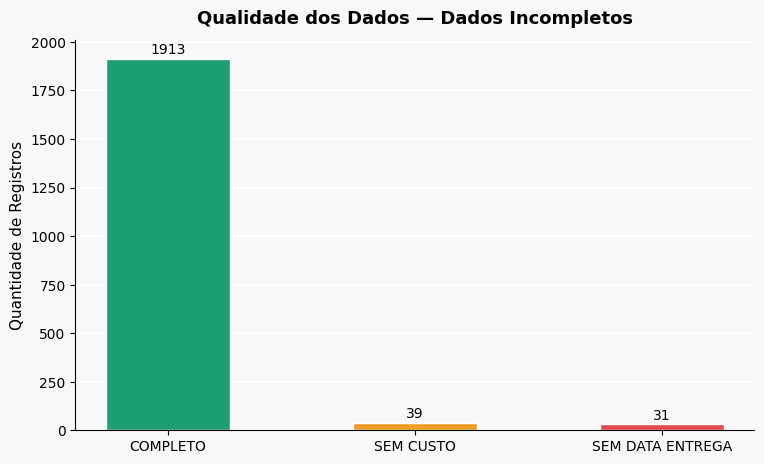

In [78]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#f9f9f8')

contagem = df['dados_incompletos'].value_counts()

cores = {
    'COMPLETO': '#1D9E75',
    'SEM CUSTO': '#EF9F27',
    'SEM DATA ENTREGA': '#E24B4A',
    'SEM CUSTO E DATA': '#7F77DD'
}

bars = ax.bar(contagem.index, contagem.values,
              color=[cores[c] for c in contagem.index],
              edgecolor='white', width=0.5)

for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=10)

ax.set_title('Qualidade dos Dados — Dados Incompletos', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Quantidade de Registros', fontsize=11)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

plt.tight_layout(pad=2)
plt.savefig('dados_incompletos.png', dpi=150, bbox_inches='tight')
plt.show()

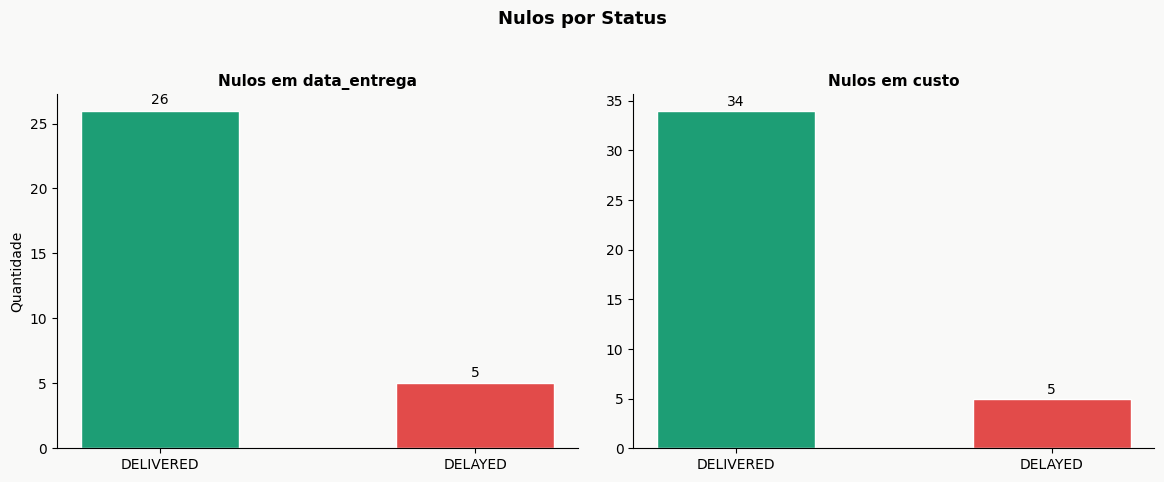

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#f9f9f8')
fig.suptitle('Nulos por Status', fontsize=13, fontweight='bold')

# nulos em data_entrega
nulos_data = df[df['data_entrega'].isna()]['status'].value_counts()
axes[0].bar(nulos_data.index, nulos_data.values,
            color=['#1D9E75', '#E24B4A'], edgecolor='white', width=0.5)
axes[0].set_title('Nulos em data_entrega', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Quantidade', fontsize=10)
axes[0].set_facecolor('#f9f9f8')
axes[0].spines[['top', 'right']].set_visible(False)
for bar, val in zip(axes[0].patches, nulos_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontsize=10)

# nulos em custo
nulos_custo = df[df['custo'].isna()]['status'].value_counts()
axes[1].bar(nulos_custo.index, nulos_custo.values,
            color=['#1D9E75', '#E24B4A'], edgecolor='white', width=0.5)
axes[1].set_title('Nulos em custo', fontsize=11, fontweight='bold')
axes[1].set_facecolor('#f9f9f8')
axes[1].spines[['top', 'right']].set_visible(False)
for bar, val in zip(axes[1].patches, nulos_custo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontsize=10)

plt.tight_layout(pad=2)
plt.savefig('nulos_por_status.png', dpi=150, bbox_inches='tight')
plt.show()

In [80]:
# registros com status DELAYED(atrasados) e nulos nas colunas custo e data_entrega
display(df[(df['status'] == 'DELAYED') &
           (df[['custo', 'data_entrega']].isnull().any(axis=1))].head(10))

,id_envio,armazem_origem,destino,transportadora,status,data_envio,data_entrega,peso_kg,custo,distancia_milhas,distancia_km,dias_transito_original,dias_transito_real,diferenca_dias,atraso_entregas,dados_incompletos
180,SH10183,Warehouse_HOU,Dallas,AMAZON LOGISTICS,DELAYED,2023-09-24,2023-10-06,7.1,NaN,1376.0,2214.45,5,12.0,7.0,ATRASADO,SEM CUSTO
256,SH10260,Warehouse_MIA,San Francisco,UPS,DELAYED,2023-07-05,NaT,14.6,358.31,2492.0,4010.48,6,NaN,NaN,ATRASADO,SEM DATA ENTREGA
462,SH10470,Warehouse_CHI,Houston,UPS,DELAYED,2023-04-21,NaT,8.7,35.59,195.0,313.82,1,NaN,NaN,ATRASADO,SEM DATA ENTREGA
1010,SH11020,Warehouse_NYC,Boston,UPS,DELAYED,2023-09-23,2023-09-28,14.9,NaN,215.0,346.01,1,5.0,4.0,ATRASADO,SEM CUSTO
1201,SH11213,Warehouse_CHI,Minneapolis,DHL,DELAYED,2023-02-18,NaT,18.5,171.77,1073.0,1726.82,3,NaN,NaN,ATRASADO,SEM DATA ENTREGA
1319,SH11333,Warehouse_CHI,San Francisco,AMAZON LOGISTICS,DELAYED,2023-04-01,NaT,9.0,67.94,435.0,700.06,2,NaN,NaN,ATRASADO,SEM DATA ENTREGA
1536,SH11552,Warehouse_SEA,Boston,ONTRAC,DELAYED,2023-01-03,NaT,184.3,497.31,1941.0,3123.73,7,NaN,NaN,ATRASADO,SEM DATA ENTREGA
1601,SH11617,Warehouse_HOU,Detroit,USPS,DELAYED,2023-09-04,2023-09-10,7.2,NaN,881.0,1417.83,5,6.0,1.0,ATRASADO,SEM CUSTO
1646,SH11662,Warehouse_CHI,Detroit,UPS,DELAYED,2023-12-09,2023-12-20,10.3,NaN,283.0,455.44,1,11.0,10.0,ATRASADO,SEM CUSTO
1831,SH11848,Warehouse_ATL,Minneapolis,AMAZON LOGISTICS,DELAYED,2023-08-01,2023-08-15,79.6,NaN,1521.0,2447.81,6,14.0,8.0,ATRASADO,SEM CUSTO


# gráfico de nulos por transportadora e armazem

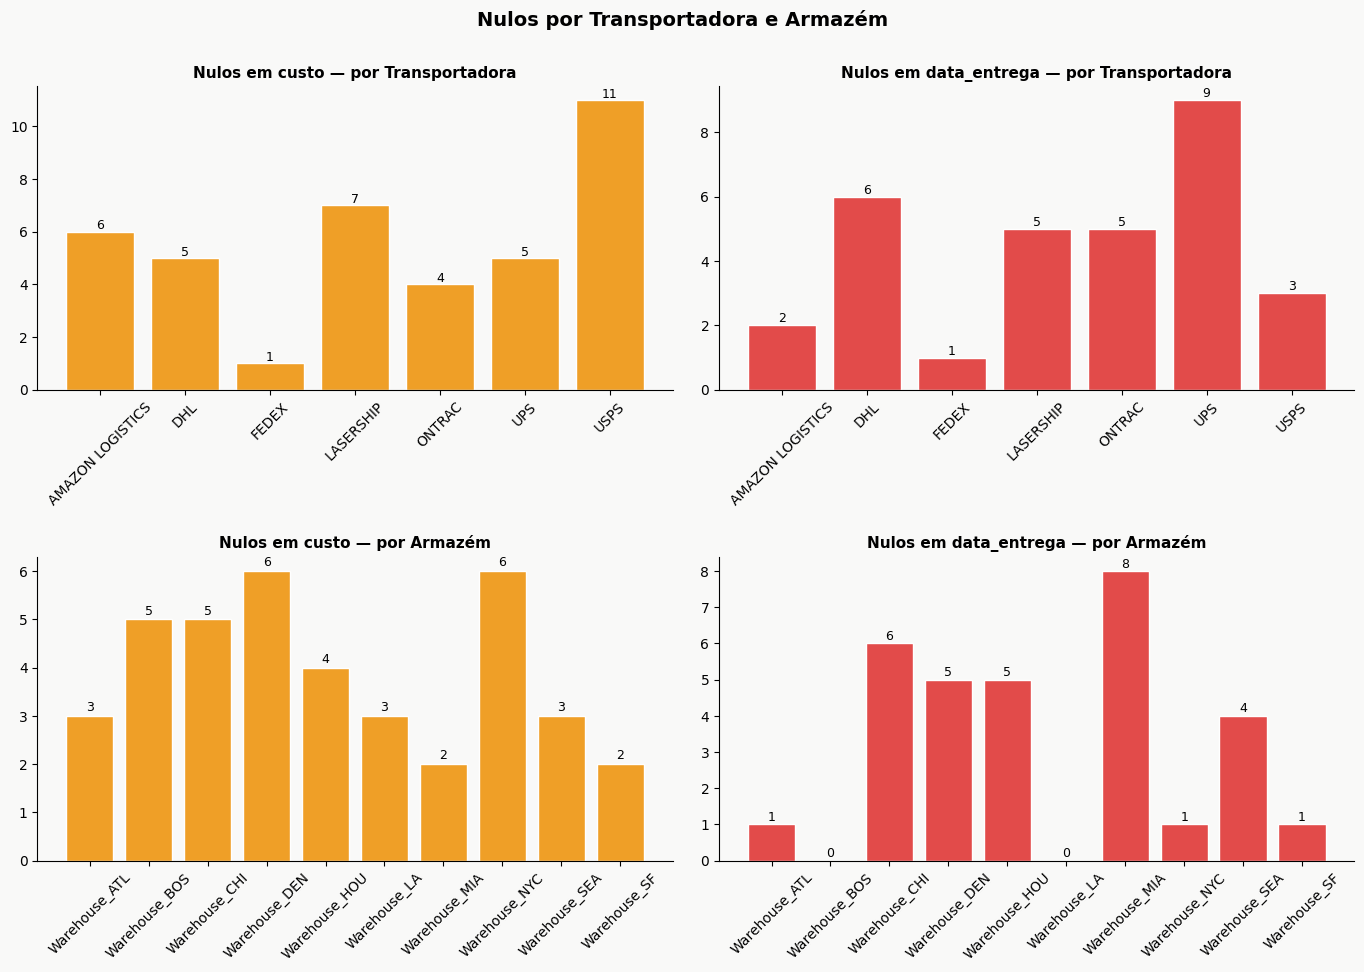

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#f9f9f8')
fig.suptitle('Nulos por Transportadora e Armazém', fontsize=14, fontweight='bold')

# nulos em custo por transportadora
nulos_custo_transp = df.groupby('transportadora')['custo'].apply(lambda x: x.isnull().sum())
axes[0, 0].bar(nulos_custo_transp.index, nulos_custo_transp.values, color='#EF9F27', edgecolor='white')
axes[0, 0].set_title('Nulos em custo — por Transportadora', fontsize=11, fontweight='bold')
axes[0, 0].set_facecolor('#f9f9f8')
axes[0, 0].spines[['top', 'right']].set_visible(False)
axes[0, 0].tick_params(axis='x', labelrotation=45)
for bar, val in zip(axes[0, 0].patches, nulos_custo_transp.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', fontsize=9)

# nulos em data_entrega por transportadora
nulos_data_transp = df.groupby('transportadora')['data_entrega'].apply(lambda x: x.isnull().sum())
axes[0, 1].bar(nulos_data_transp.index, nulos_data_transp.values, color='#E24B4A', edgecolor='white')
axes[0, 1].set_title('Nulos em data_entrega — por Transportadora', fontsize=11, fontweight='bold')
axes[0, 1].set_facecolor('#f9f9f8')
axes[0, 1].spines[['top', 'right']].set_visible(False)
axes[0, 1].tick_params(axis='x', labelrotation=45)
for bar, val in zip(axes[0, 1].patches, nulos_data_transp.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', fontsize=9)

# nulos em custo por armazem
nulos_custo_arm = df.groupby('armazem_origem')['custo'].apply(lambda x: x.isnull().sum())
axes[1, 0].bar(nulos_custo_arm.index, nulos_custo_arm.values, color='#EF9F27', edgecolor='white')
axes[1, 0].set_title('Nulos em custo — por Armazém', fontsize=11, fontweight='bold')
axes[1, 0].set_facecolor('#f9f9f8')
axes[1, 0].spines[['top', 'right']].set_visible(False)
axes[1, 0].tick_params(axis='x', labelrotation=45)
for bar, val in zip(axes[1, 0].patches, nulos_custo_arm.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', fontsize=9)

# nulos em data_entrega por armazem
nulos_data_arm = df.groupby('armazem_origem')['data_entrega'].apply(lambda x: x.isnull().sum())
axes[1, 1].bar(nulos_data_arm.index, nulos_data_arm.values, color='#E24B4A', edgecolor='white')
axes[1, 1].set_title('Nulos em data_entrega — por Armazém', fontsize=11, fontweight='bold')
axes[1, 1].set_facecolor('#f9f9f8')
axes[1, 1].spines[['top', 'right']].set_visible(False)
axes[1, 1].tick_params(axis='x', labelrotation=45)
for bar, val in zip(axes[1, 1].patches, nulos_data_arm.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', fontsize=9)

plt.tight_layout(pad=2)
plt.savefig('nulos_transportadora_armazem.png', dpi=150, bbox_inches='tight')
plt.show()

# outliers de dias_transito_original, dias_transito_real e diferenca_dias

In [82]:
# Outliers de dias_transito_original
q1 = df['dias_transito_original'].quantile(0.25)
q3 = df['dias_transito_original'].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers_dias_transito_original = df[(df['dias_transito_original'] < lim_inf) | (df['dias_transito_original'] > lim_sup)]
print(f"Outliers dias_transito_original: {len(outliers_dias_transito_original)}")

Outliers dias_transito_original: 35


In [83]:
# outliers de dias_transito_real
q1 = df['dias_transito_real'].quantile(0.25)
q3 = df['dias_transito_real'].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers_dias_transito_real = df[(df['dias_transito_real'] < lim_inf) | (df['dias_transito_real'] > lim_sup)]
len(outliers_dias_transito_real)

117

In [84]:
# Outliers de diferenca_dias
q1 = df['diferenca_dias'].quantile(0.25)
q3 = df['diferenca_dias'].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers_diferenca_dias = df[(df['diferenca_dias'] < lim_inf) | (df['diferenca_dias'] > lim_sup)]
print(f"Outliers diferenca_dias: {len(outliers_diferenca_dias)}")

Outliers diferenca_dias: 193


# nulos em outliers — método IQR

verificados os nulos dentro dos outliers identificados pelo método IQR (1.5x) para cada variável numérica.

**resultados:**
- `custo` → 4 outliers, sem nulos
- `peso_kg` → 115 outliers, 3 nulos em `custo` e 3 em `data_entrega`
- `distancia_km` → 0 outliers (distribuição uniforme)
- `dias_transito_original` → 35 outliers, 1 nulo em `data_entrega`
- `dias_transito_real` → 117 outliers, 3 nulos em `custo`
- `diferenca_dias` → 193 outliers, 5 nulos em `custo`

**conclusão:** os nulos aparecem de forma dispersa nos outliers,
sem concentração em nenhuma variável específica.

reforça que os nulos não estão associados a registros extremos.

In [85]:
# nulos dentro dos outliers (método IQR)
variaveis = ['custo', 'peso_kg', 'distancia_km', 'dias_transito_original', 'dias_transito_real', 'diferenca_dias']
colunas_nulos = ['custo', 'data_entrega']

for var in variaveis:
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers = df[(df[var] < lim_inf) | (df[var] > lim_sup)]
    nulos_por_coluna = outliers[colunas_nulos].isnull().sum()
    nulos_por_coluna = nulos_por_coluna[nulos_por_coluna > 0]

    if len(nulos_por_coluna) > 0:
        print(f'\n{var} → {len(outliers)} outliers')
        print(nulos_por_coluna)
    else:
        print(f'\n{var} → {len(outliers)} outliers — sem nulos')


custo → 4 outliers — sem nulos

peso_kg → 115 outliers
custo           3
data_entrega    3
dtype: int64

distancia_km → 0 outliers — sem nulos

dias_transito_original → 35 outliers
data_entrega    1
dtype: int64

dias_transito_real → 117 outliers
custo    3
dtype: int64

diferenca_dias → 193 outliers
custo    5
dtype: int64


# valor mínimo e máximo dos outliers de dias_transito_original, dias_transito_real e diferenca_dias

In [86]:
# Min e max outliers de dias_transito_original
min_outlier = outliers_dias_transito_original['dias_transito_original'].min()
max_outlier = outliers_dias_transito_original['dias_transito_original'].max()

print(f"O valor mínimo entre os outliers de dias_transito_original: {min_outlier}")
print(f"O valor máximo entre os outliers de dias_transito_original: {max_outlier}")

O valor mínimo entre os outliers de dias_transito_original: 9
O valor máximo entre os outliers de dias_transito_original: 12


In [87]:
# Min e max outliers de dias_transito_real
min_outlier = outliers_dias_transito_real['dias_transito_real'].min()
max_outlier = outliers_dias_transito_real['dias_transito_real'].max()

print(f"O valor mínimo entre os outliers de dias é: {min_outlier}")
print(f"O valor máximo entre os outliers de dias é: {max_outlier}")

O valor mínimo entre os outliers de dias é: 11.0
O valor máximo entre os outliers de dias é: 20.0


In [88]:
# Min e max outliers de diferenca_dias
min_outlier = outliers_diferenca_dias['diferenca_dias'].min()
max_outlier = outliers_diferenca_dias['diferenca_dias'].max()

print(f"O valor mínimo entre os outliers de diferenca_dias: {min_outlier}")
print(f"O valor máximo entre os outliers de diferenca_dias: {max_outlier}")

O valor mínimo entre os outliers de diferenca_dias: 1.0
O valor máximo entre os outliers de diferenca_dias: 13.0


# status x outliers de dias

In [89]:
#transito_original
outliers_dias_transito_original.groupby('status')['id_envio'].count()

,id_envio
status,
DELAYED,2
DELIVERED,30
IN TRANSIT,2
LOST,1


In [90]:
# nulos por coluna nos outliers de dias_transito_original
outliers_dias_transito_original[['custo', 'data_entrega']].isnull().sum()

,0
custo,0
data_entrega,1


In [91]:
#transito real
outliers_dias_transito_real.groupby('status')['id_envio'].count()

,id_envio
status,
DELAYED,113
DELIVERED,3
LOST,1


In [92]:
# nulos por coluna nos outliers de dias_transito_real
outliers_dias_transito_real[['custo', 'data_entrega']].isnull().sum()

,0
custo,3
data_entrega,0


In [93]:
#diferença de dias
outliers_diferenca_dias.groupby('status')['id_envio'].count()

,id_envio
status,
DELAYED,191
LOST,2


In [94]:
# nulos por coluna nos outliers diferenca_dias
outliers_diferenca_dias[['custo', 'data_entrega']].isnull().sum()

,0
custo,5
data_entrega,0


# comparando outliers de dias x atraso_entregas

In [95]:
# transito original
outliers_dias_transito_original.groupby('atraso_entregas')['id_envio'].count()

,id_envio
atraso_entregas,
ATRASADO,2
NO PRAZO,33


In [96]:
# transito real
outliers_dias_transito_real.groupby('atraso_entregas')['id_envio'].count()

,id_envio
atraso_entregas,
ATRASADO,113
NO PRAZO,4


In [97]:
# diferença de dias
outliers_diferenca_dias.groupby('atraso_entregas')['id_envio'].count()

,id_envio
atraso_entregas,
ATRASADO,191
NO PRAZO,2


# análise de outliers — distância, peso e custo

verifica se, dentro dos envios com trânsito e diferença de dias,
as variáveis `distancia_km`, `peso_kg` e `custo` também apresentam valores fora do padrão.

**método:** IQR aplicado dentro do subconjunto de outliers de trânsito e diferença de dias.
- `distancia_km` → 0 outliers (faixa ampla, não é fator diferenciador)
- `peso_kg` → 6 outliers (71.9 a 250.9 kg — peso elevado associado a atraso)
- `custo` → 1 outlier ($474.36 — caso limítrofe)

In [98]:
def detectar_outliers(df_sub, coluna):
    q1 = df_sub[coluna].quantile(0.25)
    q3 = df_sub[coluna].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = df_sub[(df_sub[coluna] < lim_inf) | (df_sub[coluna] > lim_sup)]
    print(f"\n{coluna}: {len(outliers)} outliers | limite [{lim_inf:.2f}, {lim_sup:.2f}]")
    print(f"  Min: {outliers[coluna].min()} | Max: {outliers[coluna].max()}")
    return outliers

# Dentro dos outliers de dias_transito_original
print("\n=== Outliers de dias_transito_original ===")
for col in ['distancia_km', 'peso_kg', 'custo']:
    detectar_outliers(outliers_dias_transito_original, col)


# Dentro dos outliers de dias_transito_real
print("\n=== Outliers de dias_transito_real ===")
for col in ['distancia_km', 'peso_kg', 'custo']:
    detectar_outliers(outliers_dias_transito_real, col)


# Dentro dos outliers de diferenca_dias
print("\n=== Outliers de diferenca_dias ===")
for col in ['distancia_km', 'peso_kg', 'custo']:
    detectar_outliers(outliers_diferenca_dias, col)


=== Outliers de dias_transito_original ===

distancia_km: 2 outliers | limite [1855.97, 4974.87]
  Min: 1548.19 | Max: 1697.85

peso_kg: 1 outliers | limite [-23.23, 68.98]
  Min: 77.8 | Max: 77.8

custo: 3 outliers | limite [175.57, 425.83]
  Min: 124.52 | Max: 430.99

=== Outliers de dias_transito_real ===

distancia_km: 0 outliers | limite [-1441.97, 5793.63]
  Min: nan | Max: nan

peso_kg: 7 outliers | limite [-15.45, 68.15]
  Min: 71.9 | Max: 250.9

custo: 1 outliers | limite [-64.80, 473.00]
  Min: 474.36 | Max: 474.36

=== Outliers de diferenca_dias ===

distancia_km: 0 outliers | limite [-2021.32, 5999.61]
  Min: nan | Max: nan

peso_kg: 9 outliers | limite [-22.50, 71.90]
  Min: 72.5 | Max: 250.9

custo: 0 outliers | limite [-114.97, 493.52]
  Min: nan | Max: nan


# quantidade de peso que gera outliers de dias

In [99]:
# dias transito original
outliers_peso = detectar_outliers(outliers_dias_transito_original, 'peso_kg')

outliers_peso[['id_envio', 'transportadora', 'armazem_origem', 'destino',
               'peso_kg', 'custo', 'diferenca_dias', 'status', 'data_entrega', 'atraso_entregas']]


peso_kg: 1 outliers | limite [-23.23, 68.98]
  Min: 77.8 | Max: 77.8


,id_envio,transportadora,armazem_origem,destino,peso_kg,custo,diferenca_dias,status,data_entrega,atraso_entregas
313,SH10318,ONTRAC,Warehouse_HOU,Los Angeles,77.8,413.72,10.0,DELAYED,2023-12-16,ATRASADO


In [100]:
# dias transito real
outliers_peso = detectar_outliers(outliers_dias_transito_real, 'peso_kg')

outliers_peso[['id_envio', 'transportadora', 'armazem_origem', 'destino',
               'peso_kg', 'custo', 'diferenca_dias', 'status', 'data_entrega', 'atraso_entregas']]


peso_kg: 7 outliers | limite [-15.45, 68.15]
  Min: 71.9 | Max: 250.9


,id_envio,transportadora,armazem_origem,destino,peso_kg,custo,diferenca_dias,status,data_entrega,atraso_entregas
313,SH10318,ONTRAC,Warehouse_HOU,Los Angeles,77.8,413.72,10.0,DELAYED,2023-12-16,ATRASADO
765,SH10774,DHL,Warehouse_SEA,New York,73.6,437.29,10.0,DELAYED,2023-04-27,ATRASADO
856,SH10865,AMAZON LOGISTICS,Warehouse_ATL,Chicago,72.5,350.54,4.0,DELAYED,2023-09-03,ATRASADO
1199,SH11211,FEDEX,Warehouse_LA,San Francisco,250.9,395.00,11.0,DELAYED,2023-06-28,ATRASADO
1586,SH11602,USPS,Warehouse_SF,Seattle,71.9,123.54,10.0,DELAYED,2023-08-09,ATRASADO
1665,SH11681,FEDEX,Warehouse_MIA,Atlanta,81.9,247.05,13.0,DELAYED,2023-04-21,ATRASADO
1831,SH11848,AMAZON LOGISTICS,Warehouse_ATL,Minneapolis,79.6,NaN,8.0,DELAYED,2023-08-15,ATRASADO


In [101]:
# diferença dias
outliers_peso = detectar_outliers(outliers_diferenca_dias, 'peso_kg')

outliers_peso[['id_envio', 'transportadora', 'armazem_origem', 'destino',
               'peso_kg', 'custo', 'diferenca_dias', 'status', 'data_entrega', 'atraso_entregas']]


peso_kg: 9 outliers | limite [-22.50, 71.90]
  Min: 72.5 | Max: 250.9


,id_envio,transportadora,armazem_origem,destino,peso_kg,custo,diferenca_dias,status,data_entrega,atraso_entregas
313,SH10318,ONTRAC,Warehouse_HOU,Los Angeles,77.8,413.72,10.0,DELAYED,2023-12-16,ATRASADO
691,SH10699,UPS,Warehouse_HOU,Dallas,78.2,195.05,2.0,DELAYED,2023-03-05,ATRASADO
765,SH10774,DHL,Warehouse_SEA,New York,73.6,437.29,10.0,DELAYED,2023-04-27,ATRASADO
856,SH10865,AMAZON LOGISTICS,Warehouse_ATL,Chicago,72.5,350.54,4.0,DELAYED,2023-09-03,ATRASADO
1199,SH11211,FEDEX,Warehouse_LA,San Francisco,250.9,395.00,11.0,DELAYED,2023-06-28,ATRASADO
1665,SH11681,FEDEX,Warehouse_MIA,Atlanta,81.9,247.05,13.0,DELAYED,2023-04-21,ATRASADO
1700,SH11716,ONTRAC,Warehouse_SEA,Portland,108.8,368.09,4.0,DELAYED,2023-06-24,ATRASADO
1831,SH11848,AMAZON LOGISTICS,Warehouse_ATL,Minneapolis,79.6,NaN,8.0,DELAYED,2023-08-15,ATRASADO
1883,SH11900,DHL,Warehouse_SEA,Atlanta,78.2,211.42,8.0,DELAYED,2023-12-22,ATRASADO


# tabela de outliers com nulos por coluna

In [102]:
variaveis = ['custo', 'peso_kg', 'distancia_km', 'dias_transito_original', 'dias_transito_real', 'diferenca_dias']

for var in variaveis:
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers = df[(df[var] < lim_inf) | (df[var] > lim_sup)]
    outliers_nulos = outliers[outliers[['custo', 'data_entrega']].isnull().any(axis=1)]

    if len(outliers_nulos) > 0:
        print(f'\n--- {var} ---')
        display(outliers_nulos[['id_envio', 'transportadora', 'armazem_origem', 'destino',
                                var, 'custo', 'data_entrega', 'status', 'atraso_entregas']])


--- peso_kg ---


,id_envio,transportadora,armazem_origem,destino,peso_kg,custo,data_entrega,status,atraso_entregas
96,SH10097,AMAZON LOGISTICS,Warehouse_MIA,Atlanta,80.4,259.98,NaT,DELIVERED,NO PRAZO
452,SH10460,USPS,Warehouse_SF,New York,68.9,NaN,2023-09-19,DELIVERED,NO PRAZO
786,SH10795,DHL,Warehouse_HOU,Chicago,77.7,NaN,2023-02-15,DELIVERED,NO PRAZO
790,SH10799,ONTRAC,Warehouse_CHI,Detroit,70.0,123.86,NaT,DELIVERED,NO PRAZO
1536,SH11552,ONTRAC,Warehouse_SEA,Boston,184.3,497.31,NaT,DELAYED,ATRASADO
1831,SH11848,AMAZON LOGISTICS,Warehouse_ATL,Minneapolis,79.6,NaN,2023-08-15,DELAYED,ATRASADO



--- dias_transito_original ---


,id_envio,transportadora,armazem_origem,destino,dias_transito_original,custo,data_entrega,status,atraso_entregas
1414,SH11428,UPS,Warehouse_CHI,Seattle,9,258.44,NaT,DELIVERED,NO PRAZO



--- dias_transito_real ---


,id_envio,transportadora,armazem_origem,destino,dias_transito_real,custo,data_entrega,status,atraso_entregas
180,SH10183,AMAZON LOGISTICS,Warehouse_HOU,Dallas,12.0,NaN,2023-10-06,DELAYED,ATRASADO
1646,SH11662,UPS,Warehouse_CHI,Detroit,11.0,NaN,2023-12-20,DELAYED,ATRASADO
1831,SH11848,AMAZON LOGISTICS,Warehouse_ATL,Minneapolis,14.0,NaN,2023-08-15,DELAYED,ATRASADO



--- diferenca_dias ---


,id_envio,transportadora,armazem_origem,destino,diferenca_dias,custo,data_entrega,status,atraso_entregas
180,SH10183,AMAZON LOGISTICS,Warehouse_HOU,Dallas,7.0,NaN,2023-10-06,DELAYED,ATRASADO
1010,SH11020,UPS,Warehouse_NYC,Boston,4.0,NaN,2023-09-28,DELAYED,ATRASADO
1601,SH11617,USPS,Warehouse_HOU,Detroit,1.0,NaN,2023-09-10,DELAYED,ATRASADO
1646,SH11662,UPS,Warehouse_CHI,Detroit,10.0,NaN,2023-12-20,DELAYED,ATRASADO
1831,SH11848,AMAZON LOGISTICS,Warehouse_ATL,Minneapolis,8.0,NaN,2023-08-15,DELAYED,ATRASADO


# transportadoras que geram mais outliers de dias

In [103]:
# transito original
outliers_dias_transito_original.groupby(['atraso_entregas', 'transportadora'])['id_envio'].count()

atraso_entregas  transportadora  
ATRASADO         FEDEX               1
                 ONTRAC              1
NO PRAZO         AMAZON LOGISTICS    9
                 DHL                 5
                 FEDEX               5
                 LASERSHIP           2
                 ONTRAC              4
                 UPS                 4
                 USPS                4
Name: id_envio, dtype: int64

In [104]:
# transito real
outliers_dias_transito_real.groupby(['atraso_entregas', 'transportadora'])['id_envio'].count()

atraso_entregas  transportadora  
ATRASADO         AMAZON LOGISTICS    20
                 DHL                 24
                 FEDEX               16
                 LASERSHIP           12
                 ONTRAC              19
                 UPS                 12
                 USPS                10
NO PRAZO         AMAZON LOGISTICS     3
                 DHL                  1
Name: id_envio, dtype: int64

In [105]:
# diferença de dias
outliers_diferenca_dias.groupby(['atraso_entregas', 'transportadora'])['id_envio'].count()

atraso_entregas  transportadora  
ATRASADO         AMAZON LOGISTICS    33
                 DHL                 38
                 FEDEX               24
                 LASERSHIP           26
                 ONTRAC              28
                 UPS                 22
                 USPS                20
NO PRAZO         AMAZON LOGISTICS     1
                 DHL                  1
Name: id_envio, dtype: int64

# armazéns que mais geram outliers de dias

In [106]:
# transito original
outliers_dias_transito_original.groupby(['atraso_entregas', 'armazem_origem'])['id_envio'].count().sort_values(ascending=False)

atraso_entregas  armazem_origem
NO PRAZO         Warehouse_ATL     5
                 Warehouse_BOS     5
                 Warehouse_HOU     4
                 Warehouse_MIA     4
                 Warehouse_NYC     3
                 Warehouse_DEN     3
                 Warehouse_CHI     3
                 Warehouse_SEA     3
                 Warehouse_SF      3
ATRASADO         Warehouse_MIA     1
                 Warehouse_HOU     1
Name: id_envio, dtype: int64

In [107]:
# transito real
outliers_dias_transito_real.groupby(['atraso_entregas', 'armazem_origem'])['id_envio'].count().sort_values(ascending=False)

atraso_entregas  armazem_origem
ATRASADO         Warehouse_ATL     16
                 Warehouse_HOU     16
                 Warehouse_MIA     14
                 Warehouse_LA      12
                 Warehouse_SF      12
                 Warehouse_CHI     11
                 Warehouse_BOS     10
                 Warehouse_SEA     10
                 Warehouse_DEN      8
                 Warehouse_NYC      4
NO PRAZO         Warehouse_BOS      2
                 Warehouse_HOU      1
                 Warehouse_LA       1
Name: id_envio, dtype: int64

In [108]:
# diferença de dias
outliers_diferenca_dias.groupby(['atraso_entregas', 'armazem_origem'])['id_envio'].count().sort_values(ascending=False)

atraso_entregas  armazem_origem
ATRASADO         Warehouse_HOU     25
                 Warehouse_SF      24
                 Warehouse_ATL     22
                 Warehouse_MIA     22
                 Warehouse_LA      22
                 Warehouse_BOS     17
                 Warehouse_CHI     17
                 Warehouse_DEN     16
                 Warehouse_SEA     16
                 Warehouse_NYC     10
NO PRAZO         Warehouse_ATL      1
                 Warehouse_LA       1
Name: id_envio, dtype: int64

# gráfico de outliers de custo, peso e distancia_km

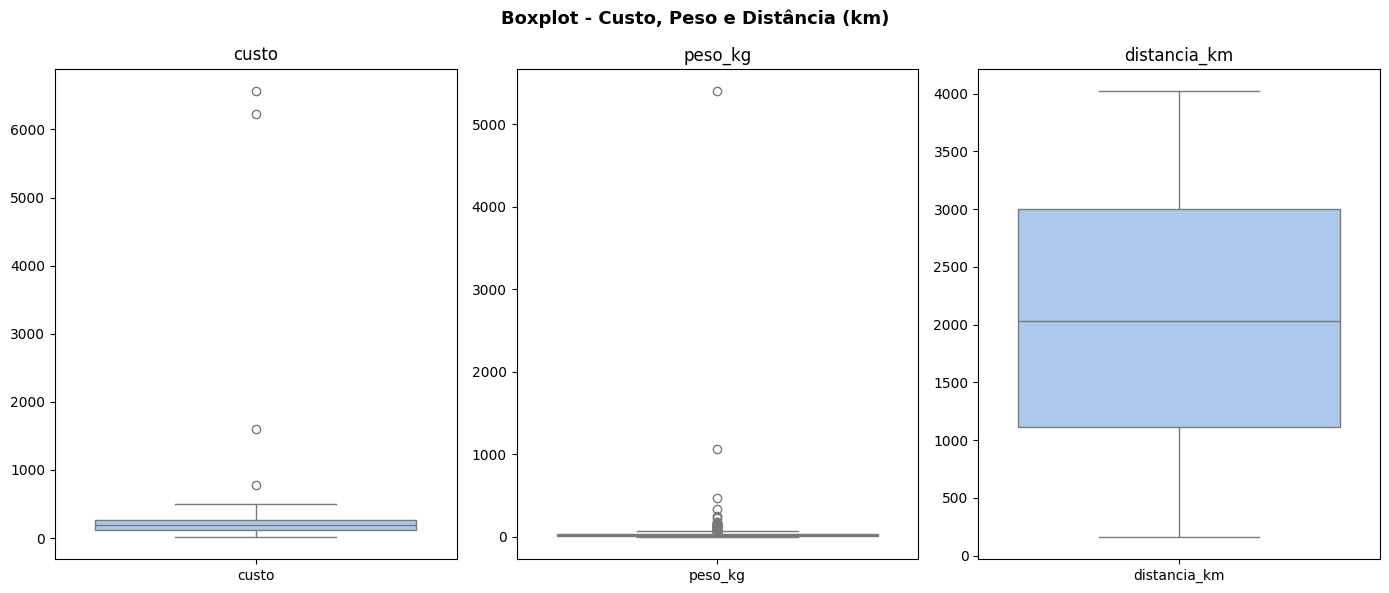

In [109]:
cols = ['custo', 'peso_kg', 'distancia_km']

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for ax, col in zip(axes, cols):
    sns.boxplot(data=df[[col]], palette='pastel', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Boxplot - Custo, Peso e Distância (km)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# gráfico de outliers de dias_transito_original, dias_transito_real e diferenca_dias.

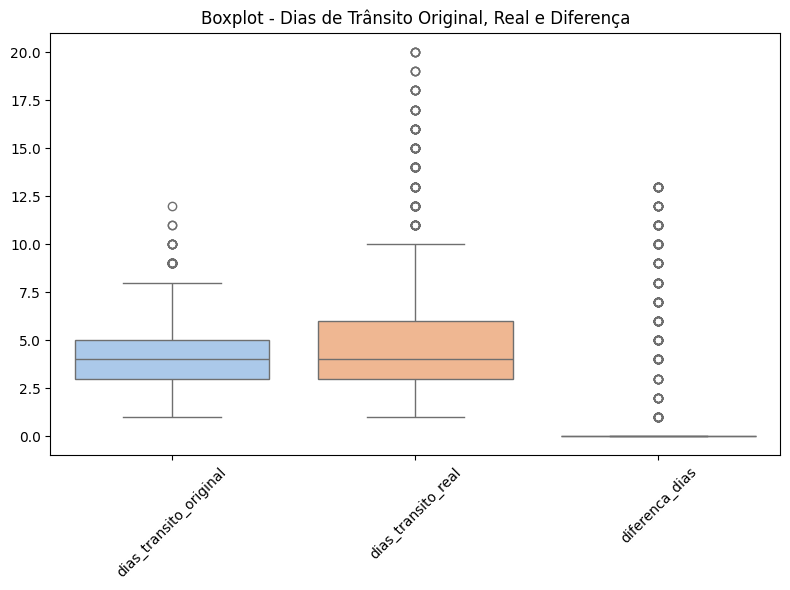

In [110]:
cols = ['dias_transito_original', 'dias_transito_real', 'diferenca_dias']

plt.figure(figsize=(8, 6))
sns.boxplot(data=df[cols], palette='pastel')
plt.xticks(rotation=45)
plt.title('Boxplot - Dias de Trânsito Original, Real e Diferença')
plt.tight_layout()
plt.show()

# gráfico de nulos outliers

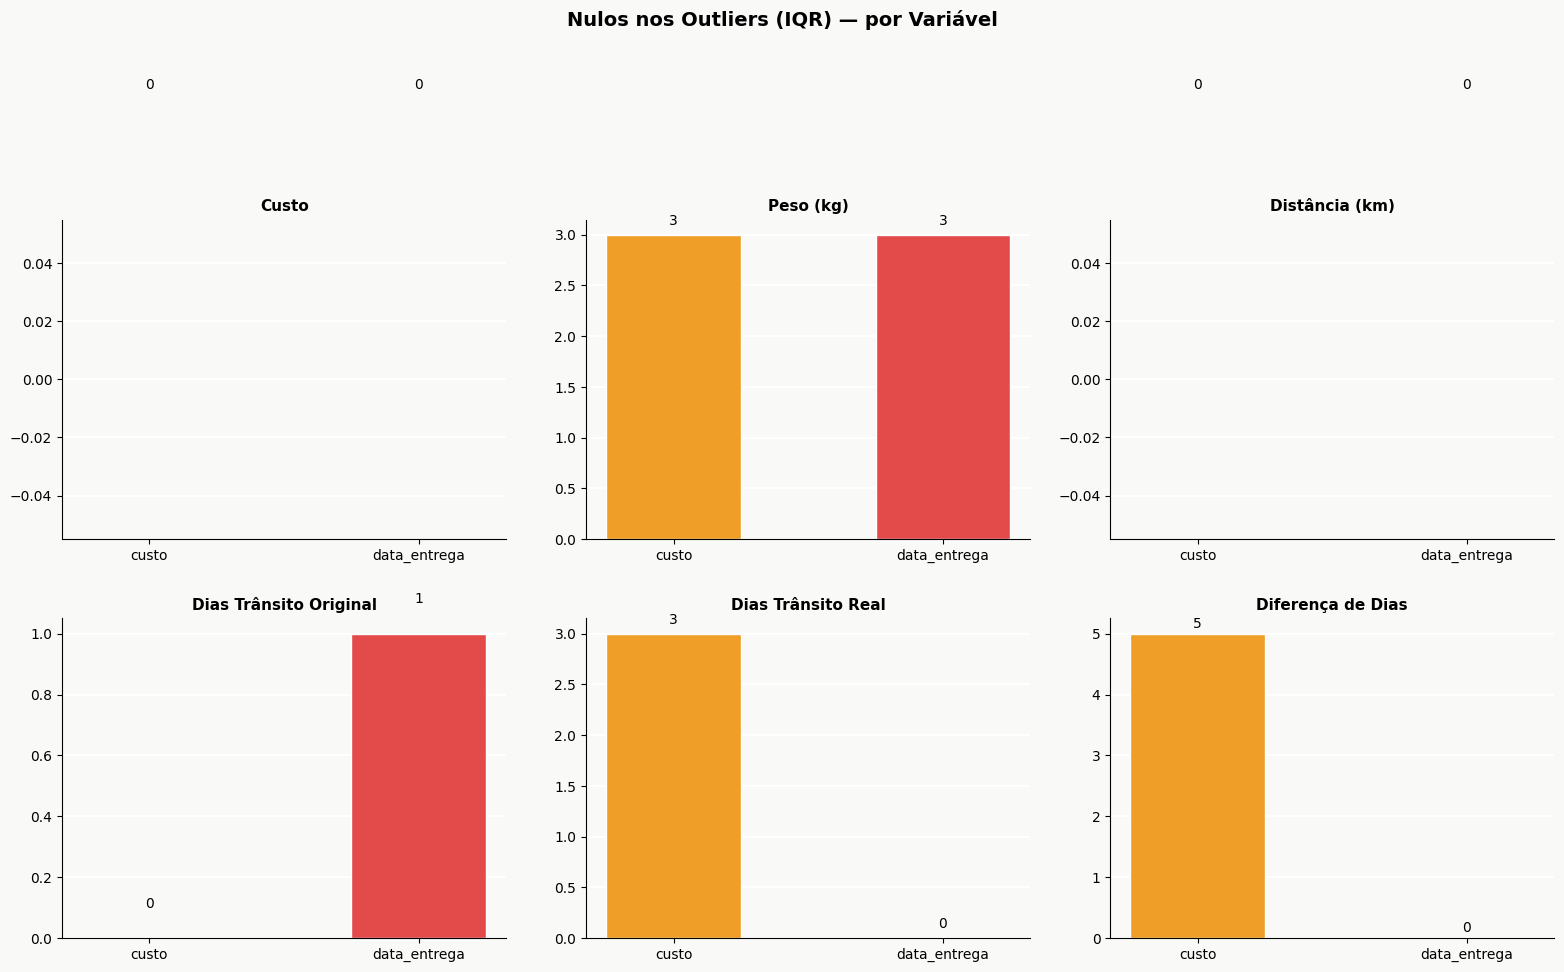

In [111]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#f9f9f8')
fig.suptitle('Nulos nos Outliers (IQR) — por Variável', fontsize=14, fontweight='bold')

variaveis = ['custo', 'peso_kg', 'distancia_km', 'dias_transito_original', 'dias_transito_real', 'diferenca_dias']
titulos   = ['Custo', 'Peso (kg)', 'Distância (km)', 'Dias Trânsito Original', 'Dias Trânsito Real', 'Diferença de Dias']

for ax, var, titulo in zip(axes.flat, variaveis, titulos):
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers = df[(df[var] < lim_inf) | (df[var] > lim_sup)]
    nulos = outliers[['custo', 'data_entrega']].isnull().sum()

    bars = ax.bar(nulos.index, nulos.values, color=['#EF9F27', '#E24B4A'], edgecolor='white', width=0.5)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_facecolor('#f9f9f8')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, color='white', linewidth=1.5)
    ax.set_axisbelow(True)

    for bar, val in zip(bars, nulos.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha='center', fontsize=10)

plt.tight_layout(pad=2)
plt.savefig('nulos_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# análise de estatísticas descritivas

calculadas média, mínimo, máximo e percentil 90 das variáveis principais, sem criação de colunas adicionais no df.

considera-se somente colunas numéricas.

os cálculos excluem automaticamente os nulos presentes em `custo` e `data_entrega`.

**resultados:**

| Variável               | Média   | Mínimo | Máximo  | Percentil 90 |
|------------------------|---------|--------|---------|--------------|
| custo                  | 205.15  | 17.89  | 6562.21 | 324.85       |
| peso_kg                | 30.22   | 0.00   | 5404.20 | 51.96        |
| distancia_km           | 2052.78 | 162.54 | 4021.74 | 3621.02      |
| dias_transito_original | 4.18    | 1.00   | 12.00   | 6.00         |
| dias_transito_real     | 4.90    | 1.00   | 20.00   | 8.00         |
| diferenca_dias         | 0.71    | 0.00   | 13.00   | 0.00         |


**insights identificados:**
- `custo` tem outliers severos: média de 205 mas máximo de 6562
- `peso_kg` também: média de 30kg mas máximo de 5404kg — envios muito discrepantes
- `dias_transito_real` chega a 20 dias contra máximo original de 12 — diferença de até 8 dias
- Percentil 90 de `diferenca_dias` igual a zero significa que 90% dos envios não ultrapassam o prazo previsto

In [112]:
# Estatísticas descritivas das variáveis principais
variaveis = ['custo', 'peso_kg', 'distancia_km', 'dias_transito_original', 'dias_transito_real', 'diferenca_dias']

estatisticas = df[variaveis].agg(['mean', 'min', 'max']).T

# Adiciona percentil 90
estatisticas['percentil_90'] = df[variaveis].quantile(0.9)

print(estatisticas.round(2))

                           mean     min      max  percentil_90
custo                    205.15   17.89  6562.21        324.85
peso_kg                   30.22    0.00  5404.20         51.96
distancia_km            2052.78  162.54  4021.74       3621.02
dias_transito_original     4.18    1.00    12.00          6.00
dias_transito_real         4.90    1.00    20.00          8.00
diferenca_dias             0.71    0.00    13.00          0.00


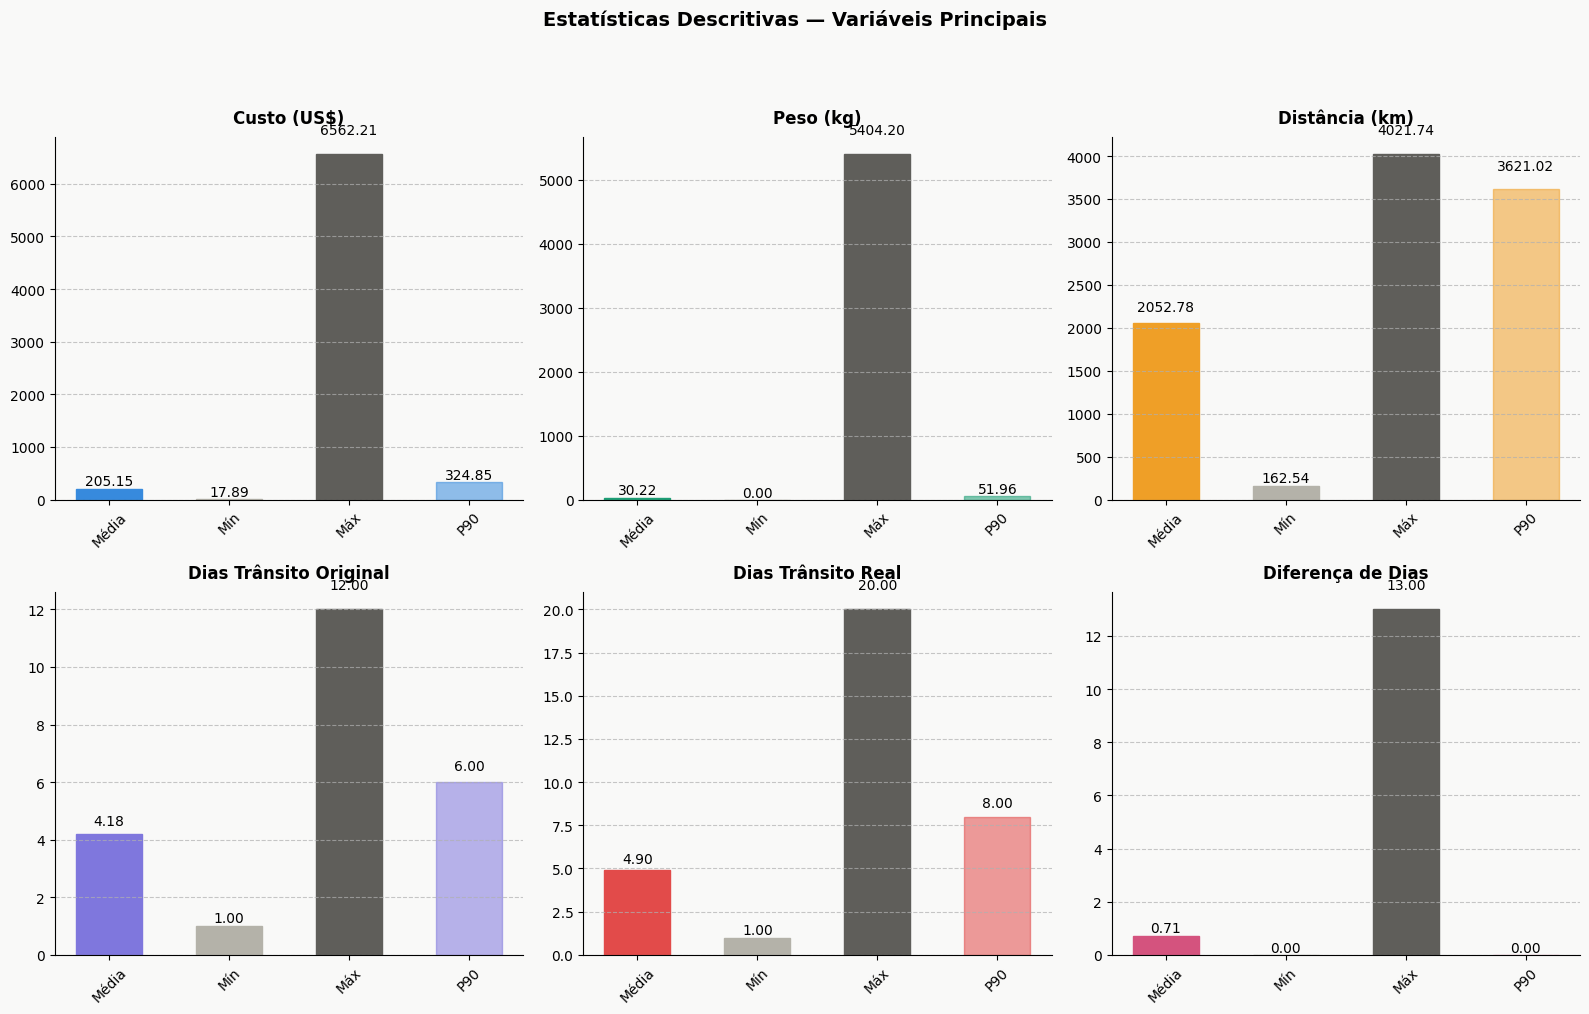

In [113]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#f9f9f8')
fig.suptitle('Estatísticas Descritivas — Variáveis Principais', fontsize=14, fontweight='bold', y=1.01)

variaveis = ['custo', 'peso_kg', 'distancia_km', 'dias_transito_original', 'dias_transito_real', 'diferenca_dias']
titulos   = ['Custo (US$)', 'Peso (kg)', 'Distância (km)', 'Dias Trânsito Original', 'Dias Trânsito Real', 'Diferença de Dias']
cor_barra = ['#378ADD', '#1D9E75', '#EF9F27', '#7F77DD', '#E24B4A', '#D4537E']

for ax, var, titulo, cor in zip(axes.flat, variaveis, titulos, cor_barra):
    row = estatisticas.loc[var]
    metricas = ['mean', 'min', 'max', 'percentil_90']
    labels   = ['Média', 'Mín', 'Máx', 'P90']
    valores  = [row[m] for m in metricas]

    bars = ax.bar(labels, valores, color=[cor, '#B4B2A9', '#888780', cor + 'aa'],
                  edgecolor='white', width=0.55)

    # Cor distinta para cada barra
    bars[0].set_color(cor)
    bars[1].set_color('#B4B2A9')
    bars[2].set_color('#5F5E5A')
    bars[3].set_color(cor)
    bars[3].set_alpha(0.55)

    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (bar.get_height() * 0.05),
                f'{val:.2f}', ha='center', va='bottom')

    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.set_facecolor('#f9f9f8')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('estatisticas_descritivas.png', dpi=150, bbox_inches='tight')
plt.show()

# média dos nulos em custo e data_entrega

In [114]:
print(df[['custo', 'data_entrega']].isnull().mean() * 100)

custo           1.966717
data_entrega    1.563288
dtype: float64


# taxa de atraso por transportadora

agrupamento por `transportadora` para calcular o desempenho de cada carrier em relação aos atrasos.

**métricas calculadas:**
- `total_envios` → total de envios por transportadora
- `total_atrasados` → quantidade de envios classificados como ATRASADO
- `taxa_atraso` → percentual de envios atrasados sobre o total

**insights identificados:**
- DHL apresenta a maior taxa de atraso (13.93%)
- USPS é a transportadora mais confiável com menor taxa de atraso (6.99%)
- Amazon Logistics surpreende negativamente com 12.55% de atraso, apesar de operar rede própria

In [115]:
# calculando com os atrasados da coluna atraso_entregas
taxa_atraso = (
    df.groupby('transportadora')
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('atraso_entregas', lambda x: (x == 'ATRASADO').sum())
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_envios'] * 100).round(2))
    .sort_values('taxa_atraso', ascending=False)
)

print(taxa_atraso)

                  total_envios  total_atrasados  taxa_atraso
transportadora                                              
DHL                        280               39        13.93
AMAZON LOGISTICS           271               34        12.55
ONTRAC                     297               29         9.76
UPS                        256               24         9.38
LASERSHIP                  302               26         8.61
FEDEX                      291               24         8.25
USPS                       286               20         6.99


In [116]:
# calculando com os atrasados da coluna status
taxa_atraso = (
    df.groupby('transportadora')
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('status', lambda x: (x == 'DELAYED').sum())
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_envios'] * 100).round(2))
    .sort_values('taxa_atraso', ascending=False)
)

print(taxa_atraso)

                  total_envios  total_atrasados  taxa_atraso
transportadora                                              
DHL                        280               39        13.93
AMAZON LOGISTICS           271               34        12.55
ONTRAC                     297               29         9.76
UPS                        256               24         9.38
LASERSHIP                  302               26         8.61
FEDEX                      291               24         8.25
USPS                       286               20         6.99


In [117]:
#atraso por transportadora pela coluna status
df.groupby(['transportadora', 'status'])['id_envio'].count().unstack(fill_value=0).sort_values('DELAYED', ascending=False)

status,DELAYED,DELIVERED,IN TRANSIT,LOST,RETURNED
transportadora,,,,,
DHL,39,230,8,1,2
AMAZON LOGISTICS,34,214,8,12,3
ONTRAC,29,246,11,4,7
LASERSHIP,26,248,13,10,5
FEDEX,24,242,12,6,7
UPS,24,221,8,0,3
USPS,20,235,15,12,4


In [118]:
#atraso por transportadora pela coluna atraso_entregas
df.groupby(['transportadora', 'atraso_entregas'])['id_envio'].count().unstack(fill_value=0).sort_values('ATRASADO', ascending=False)

atraso_entregas,ATRASADO,NO PRAZO
transportadora,,
DHL,39,241
AMAZON LOGISTICS,34,237
ONTRAC,29,268
LASERSHIP,26,276
FEDEX,24,267
UPS,24,232
USPS,20,266


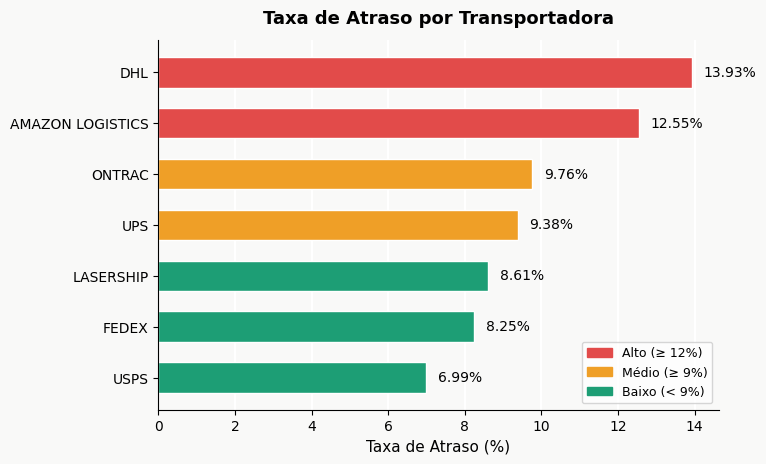

In [119]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#f9f9f8')

transportadoras = taxa_atraso.index.tolist()
taxas = taxa_atraso['taxa_atraso'].tolist()

cores = ['#E24B4A' if t >= 12 else '#EF9F27' if t >= 9 else '#1D9E75' for t in taxas]

bars = ax.barh(transportadoras, taxas, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Taxa de Atraso (%)', fontsize=11)
ax.set_title('Taxa de Atraso por Transportadora', fontsize=13, fontweight='bold', pad=12)
ax.invert_yaxis()
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, taxas):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto (≥ 12%)')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio (≥ 9%)')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo (< 9%)')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('taxa_atraso.png', dpi=150, bbox_inches='tight')
plt.show()

# taxa de atraso por rota

agrupamento por `armazem_origem` e `destino` para calcular o desempenho de cada rota em relação aos atrasos.

**métricas calculadas:**
- `total_envios` → total de envios por rota
- `total_atrasados` → quantidade de envios classificados como ATRASADO
- `taxa_atraso` → percentual de envios atrasados sobre o total

**insights identificados:**
- Warehouse_NYC → Boston lidera com a maior taxa de atraso (40.00%) com apenas 5 envios
- Warehouse_CHI → Phoenix e Warehouse_HOU → Chicago empatam em segundo (25.00%)
- Warehouse_ATL → Boston tem o maior volume do top 10 (17 envios) com taxa de 23.53%
- Warehouse_NYC → Boston tem o menor volume (5 envios) — interpretar com cautela

**observação:** rotas com poucos envios devem ser interpretadas com cautela, pois cada atraso representa uma fatia maior do total.

In [120]:
# Taxa de atraso por rota considerando atrasados pela coluna atraso_entregas
taxa_atraso_rota = (
    df.groupby(['armazem_origem', 'destino'])
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('atraso_entregas', lambda x: (x == 'ATRASADO').sum())
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_envios'] * 100).round(2))
    .sort_values('taxa_atraso', ascending=False)
    .head(10)
)

print(taxa_atraso_rota)

                              total_envios  total_atrasados  taxa_atraso
armazem_origem destino                                                  
Warehouse_NYC  Boston                    5                2        40.00
Warehouse_CHI  Phoenix                   8                2        25.00
Warehouse_HOU  Chicago                  16                4        25.00
Warehouse_MIA  Boston                   12                3        25.00
Warehouse_SEA  Boston                   12                3        25.00
Warehouse_ATL  Boston                   17                4        23.53
Warehouse_LA   Seattle                  13                3        23.08
Warehouse_DEN  New York                 13                3        23.08
Warehouse_BOS  San Francisco             9                2        22.22
Warehouse_ATL  Los Angeles               9                2        22.22


In [121]:
# taxa de atraso por rota considerando atrasados pela coluna status
taxa_atraso_rota = (
    df.groupby(['armazem_origem', 'destino'])
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('status', lambda x: (x == 'DELAYED').sum())
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_envios'] * 100).round(2))
    .sort_values('taxa_atraso', ascending=False)
)

print(taxa_atraso_rota.head(10))

                              total_envios  total_atrasados  taxa_atraso
armazem_origem destino                                                  
Warehouse_NYC  Boston                    5                2        40.00
Warehouse_CHI  Phoenix                   8                2        25.00
Warehouse_HOU  Chicago                  16                4        25.00
Warehouse_MIA  Boston                   12                3        25.00
Warehouse_SEA  Boston                   12                3        25.00
Warehouse_ATL  Boston                   17                4        23.53
Warehouse_LA   Seattle                  13                3        23.08
Warehouse_DEN  New York                 13                3        23.08
Warehouse_BOS  San Francisco             9                2        22.22
Warehouse_ATL  Los Angeles               9                2        22.22


In [122]:
# Total de atrasados por armazém e destino
(
    df.groupby(['armazem_origem', 'destino', 'atraso_entregas'])['id_envio']
    .count()
    .unstack(fill_value=0)
    .assign(total=lambda x: x['ATRASADO'] + x['NO PRAZO'])
    .sort_values('ATRASADO', ascending=False)
)

atraso_entregas             ATRASADO  NO PRAZO  total
armazem_origem destino                               
Warehouse_ATL  Boston              4        13     17
               Minneapolis         4        15     19
Warehouse_HOU  Detroit             4        14     18
               Chicago             4        12     16
Warehouse_SF   Denver              3        11     14
...                              ...       ...    ...
Warehouse_SEA  Minneapolis         0        13     13
Warehouse_SF   Chicago             0        12     12
               Los Angeles         0         9      9
               Minneapolis         0        16     16
               Portland            0        17     17

[150 rows x 3 columns]

In [123]:
# Total de atrasados por armazém
(
    df.groupby(['armazem_origem', 'atraso_entregas'])['id_envio']
    .count()
    .unstack(fill_value=0)
    .assign(total=lambda x: x['ATRASADO'] + x['NO PRAZO'])
    .sort_values('ATRASADO', ascending=False)
)

atraso_entregas,ATRASADO,NO PRAZO,total
armazem_origem,,,
Warehouse_HOU,25,186,211
Warehouse_SF,24,190,214
Warehouse_MIA,23,176,199
Warehouse_ATL,22,181,203
Warehouse_LA,22,196,218
Warehouse_CHI,20,175,195
Warehouse_BOS,17,175,192
Warehouse_SEA,17,172,189
Warehouse_DEN,16,179,195


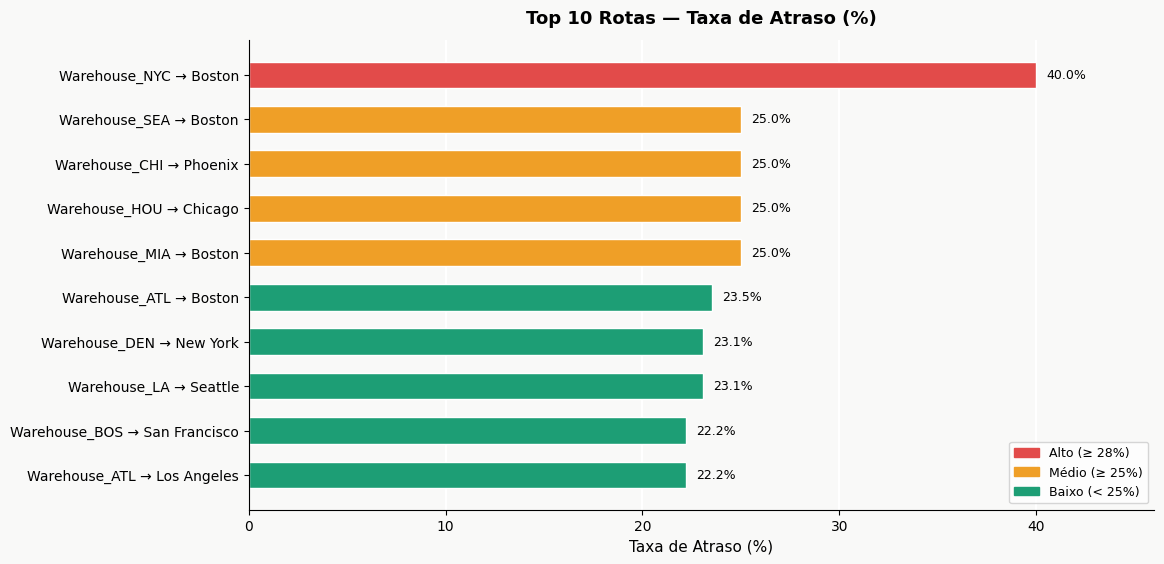

In [124]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f9f9f8')

taxa_atraso_rota_plot = taxa_atraso_rota.nlargest(10, 'taxa_atraso').copy()
taxa_atraso_rota_plot['rota'] = (
    taxa_atraso_rota_plot.index.get_level_values('armazem_origem') + ' → ' +
    taxa_atraso_rota_plot.index.get_level_values('destino')
)
taxa_atraso_rota_plot = taxa_atraso_rota_plot.sort_values('taxa_atraso', ascending=True)

rotas = taxa_atraso_rota_plot['rota'].tolist()
taxas = taxa_atraso_rota_plot['taxa_atraso'].tolist()

cores = ['#E24B4A' if t >= 28 else '#EF9F27' if t >= 25 else '#1D9E75' for t in taxas]

bars = ax.barh(rotas, taxas, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Taxa de Atraso (%)', fontsize=11)
ax.set_title('Top 10 Rotas — Taxa de Atraso (%)', fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, taxas):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlim(0, max(taxas) * 1.15)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto (≥ 28%)')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio (≥ 25%)')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo (< 25%)')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('taxa_atraso_rotas.png', dpi=150, bbox_inches='tight')
plt.show()

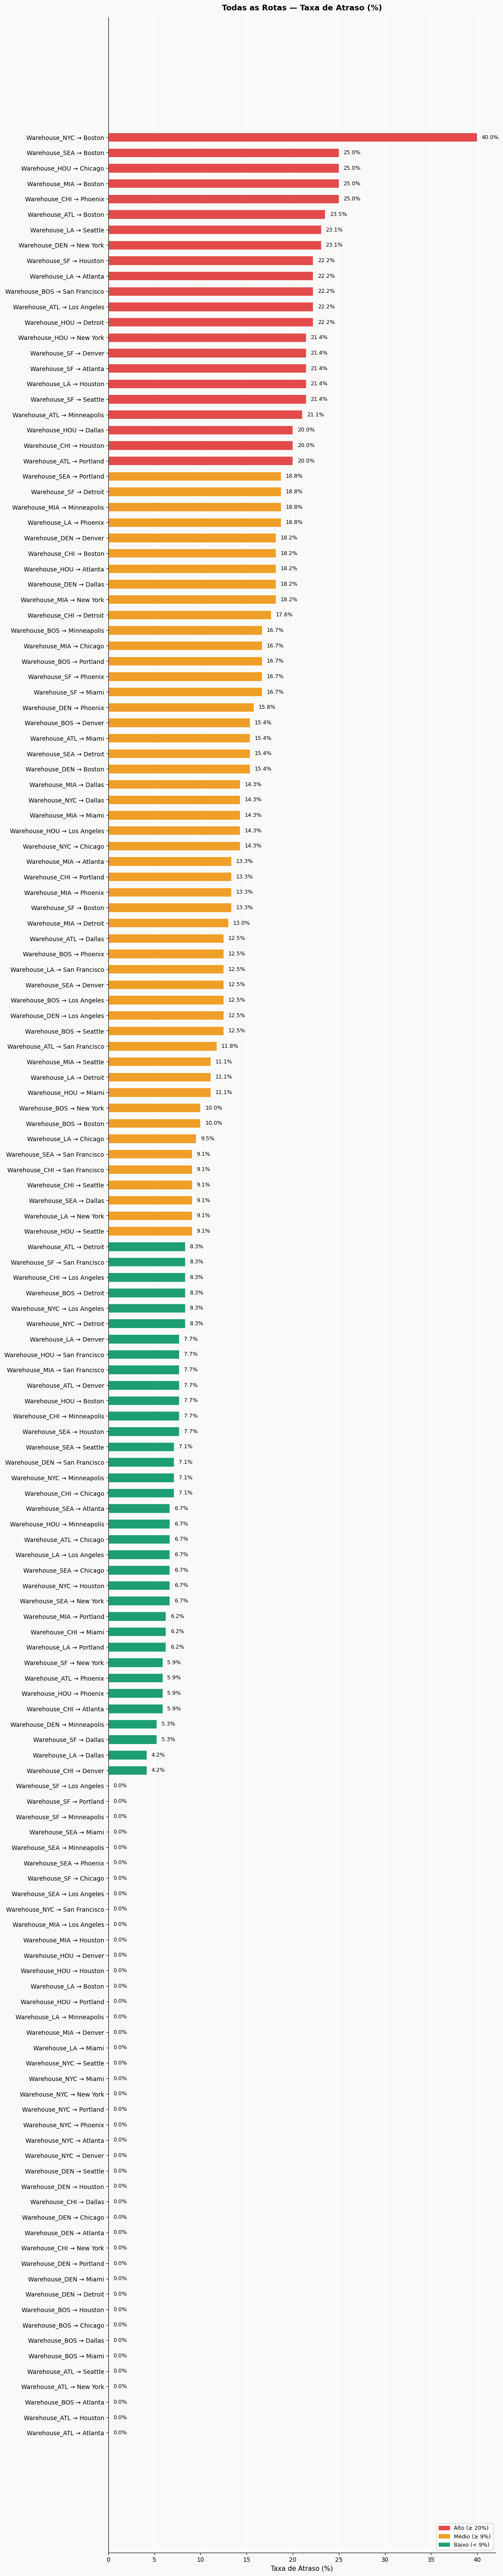

In [125]:
# Calcula todas as rotas sem head(10)
taxa_atraso_todas = (
    df.groupby(['armazem_origem', 'destino'])
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('atraso_entregas', lambda x: (x == 'ATRASADO').sum())
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_envios'] * 100).round(2))
    .sort_values('taxa_atraso', ascending=True)
)

taxa_atraso_todas['rota'] = (
    taxa_atraso_todas.index.get_level_values('armazem_origem') + ' → ' +
    taxa_atraso_todas.index.get_level_values('destino')
)

rotas = taxa_atraso_todas['rota'].tolist()
taxas = taxa_atraso_todas['taxa_atraso'].tolist()

fig, ax = plt.subplots(figsize=(12, len(rotas) * 0.4))
fig.patch.set_facecolor('#f9f9f8')

cores = ['#E24B4A' if t >= 20 else '#EF9F27' if t >= 9 else '#1D9E75' for t in taxas]

bars = ax.barh(rotas, taxas, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Taxa de Atraso (%)', fontsize=11)
ax.set_title('Todas as Rotas — Taxa de Atraso (%)', fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, taxas):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto (≥ 20%)')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio (≥ 9%)')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo (< 9%)')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('taxa_atraso_todas_rotas.png', dpi=150, bbox_inches='tight')
plt.show()

# taxa de atraso por destino

agrupamento por destino para identificar as cidades com maior proporção de entregas atrasadas.

**métricas calculadas:**
- `total_envios` → total de envios por destino
- `total_atrasados` → quantidade de envios com status DELAYED
- `taxa_atraso` → percentual de envios atrasados sobre o total

**classificação:**
- alto (≥ 10%) → destinos críticos
- baixo (< 10%) → destinos com bom desempenho

**insights identificados:**
- Boston é o destino mais crítico com 16.95% de taxa e menor volume (118 envios)
- Detroit é o segundo pior destino com 13.67%
- Chicago tem o maior volume (154 envios) e taxa de 9.09%
- Miami é o destino mais confiável com apenas 6.61% de atraso

In [126]:
# taxa de atraso por destino considerando atrasados pela coluna atraso_entregas
taxa_atraso_destino = (
    df.groupby('destino')
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('atraso_entregas', lambda x: (x == 'ATRASADO').sum())
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_envios'] * 100).round(2))
    .sort_values('taxa_atraso', ascending=False)
)

print(taxa_atraso_destino)

               total_envios  total_atrasados  taxa_atraso
destino                                                  
Boston                  118               20        16.95
Detroit                 139               19        13.67
Phoenix                 146               17        11.64
New York                117               13        11.11
Seattle                 109               11        10.09
Dallas                  136               13         9.56
San Francisco           128               12         9.38
Chicago                 154               14         9.09
Minneapolis             147               13         8.84
Los Angeles             125               11         8.80
Denver                  140               12         8.57
Portland                145               12         8.28
Atlanta                 133               11         8.27
Houston                 125               10         8.00
Miami                   121                8         6.61


In [127]:
# taxa de atraso por destino considerando atrasados pela coluna status
taxa_atraso_destino = (
    df.groupby('destino')
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('status', lambda x: (x == 'DELAYED').sum())
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_envios'] * 100).round(2))
    .sort_values('taxa_atraso', ascending=False)
)

print(taxa_atraso_destino)

               total_envios  total_atrasados  taxa_atraso
destino                                                  
Boston                  118               20        16.95
Detroit                 139               19        13.67
Phoenix                 146               17        11.64
New York                117               13        11.11
Seattle                 109               11        10.09
Dallas                  136               13         9.56
San Francisco           128               12         9.38
Chicago                 154               14         9.09
Minneapolis             147               13         8.84
Los Angeles             125               11         8.80
Denver                  140               12         8.57
Portland                145               12         8.28
Atlanta                 133               11         8.27
Houston                 125               10         8.00
Miami                   121                8         6.61


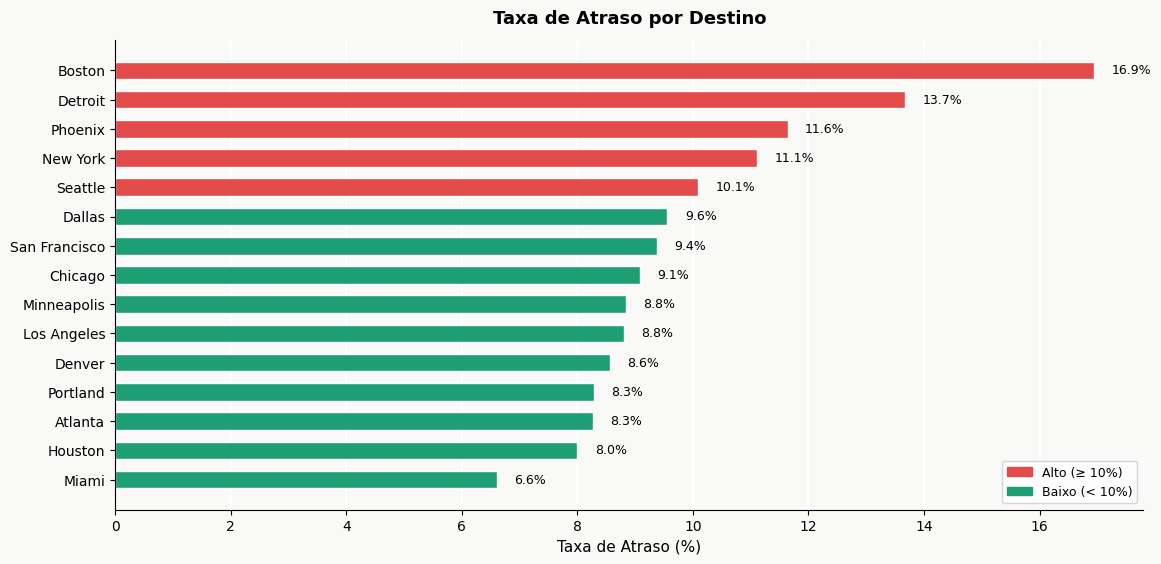

In [128]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f9f9f8')

destinos = taxa_atraso_destino.index.tolist()
taxas = taxa_atraso_destino['taxa_atraso'].tolist()

cores = ['#E24B4A' if t >= 10 else '#1D9E75' for t in taxas]

bars = ax.barh(destinos, taxas, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Taxa de Atraso (%)', fontsize=11)
ax.set_title('Taxa de Atraso por Destino', fontsize=13, fontweight='bold', pad=12)
ax.invert_yaxis()
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, taxas):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto (≥ 10%)')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo (< 10%)')
ax.legend(handles=[p_verm, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('taxa_atraso_destino.png', dpi=150, bbox_inches='tight')
plt.show()

# análise de custo por km

calculada a métrica `custo_por_km` diretamente no agrupamento, sem criação
de coluna adicional no df, dividindo o custo pelo total de km percorridos.

**top 3 rotas com maior custo por km:**
- Warehouse_LA para San Francisco: 0.29 por km (maior custo - rota curta com custo fixo alto)
- Warehouse_NYC para Boston: 0.19 por km
- Warehouse_HOU para Detroit: 0.18 por km

**insight identificado**

- rotas mais curtas tendem a apresentar maior custo por km, pois o custo fixo
do envio é diluído em menos quilômetros.
- Warehouse_LA para San Francisco se
destaca com custo quase o dobro da segunda colocada, sugerindo ineficiência
logística ou tarifa diferenciada nesse trajeto.

In [129]:
# media de custo por km - top 10
custo_por_km_rota = (
    df[(df['distancia_km'] > 0) & (df['custo'].notna())] # excluir distancia menor que o e nulos em custo
    .groupby(['armazem_origem', 'destino'])
    .apply(lambda x: (x['custo'] / x['distancia_km']).mean())
    .reset_index(name='media_custo_por_km')
    .sort_values('media_custo_por_km', ascending=False)
)

print(custo_por_km_rota.head(10))

    armazem_origem        destino  media_custo_por_km
88    Warehouse_LA  San Francisco            0.291714
106  Warehouse_NYC         Boston            0.193116
65   Warehouse_HOU        Detroit            0.185988
32   Warehouse_CHI        Chicago            0.171439
7    Warehouse_ATL    Los Angeles            0.160039
35   Warehouse_CHI        Detroit            0.157510
82    Warehouse_LA    Los Angeles            0.140521
96   Warehouse_MIA        Houston            0.137857
122  Warehouse_SEA        Chicago            0.137545
76    Warehouse_LA         Boston            0.136434


/tmp/ipykernel_18557/2690066816.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['custo'] / x['distancia_km']).mean())


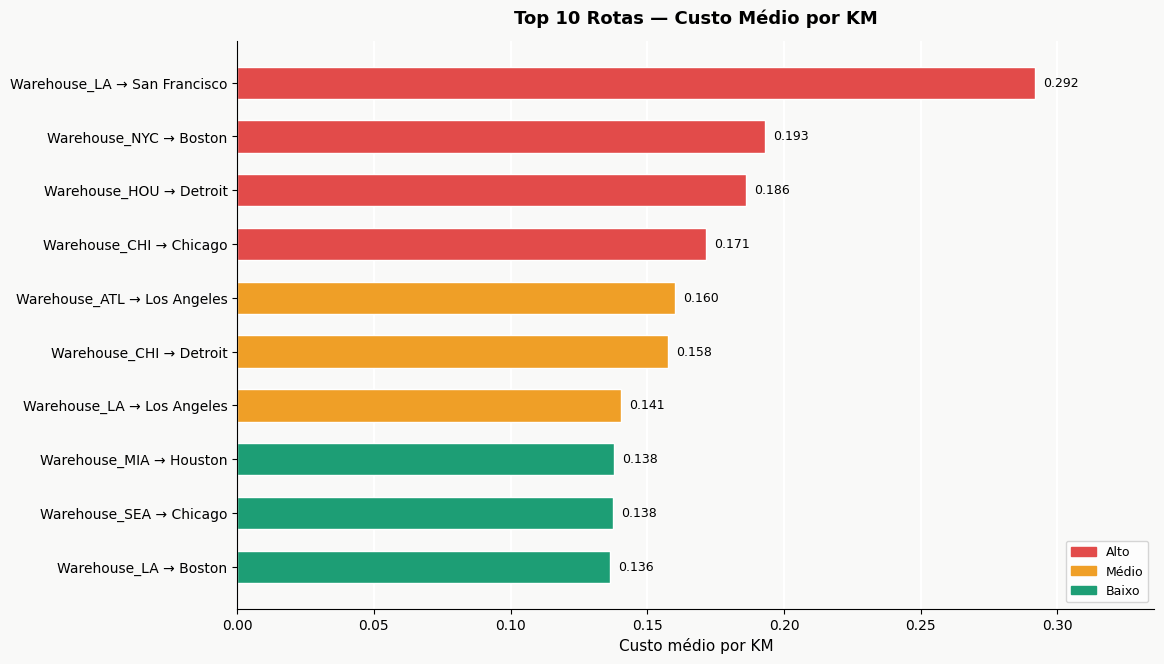

In [130]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f9f9f8')

custo_plot = custo_por_km_rota.nlargest(10, 'media_custo_por_km').copy()
custo_plot['rota'] = custo_plot['armazem_origem'] + ' → ' + custo_plot['destino']
custo_plot = custo_plot.sort_values('media_custo_por_km', ascending=True)

rotas  = custo_plot['rota'].tolist()
custos = custo_plot['media_custo_por_km'].tolist()

def cor(i, total):
    t = i / (total - 1)
    if t >= 0.66: return '#E24B4A'
    if t >= 0.33: return '#EF9F27'
    return '#1D9E75'

cores = [cor(i, len(custos)) for i in range(len(custos))]

bars = ax.barh(rotas, custos, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Custo médio por KM', fontsize=11)
ax.set_title('Top 10 Rotas — Custo Médio por KM', fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, custos):
    ax.text(val + max(custos) * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlim(0, max(custos) * 1.15)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('custo_por_km_rotas.png', dpi=150, bbox_inches='tight')
plt.show()

# análise de custo por peso

- métrica `custo_por_kg` calculada diretamente no agrupamento, sem criação de coluna adicional no df
- envios com peso igual a zero foram excluídos para evitar divisão por zero

**top 3 rotas com maior custo por kg:**
- Warehouse_HOU → Seattle: 115.69/kg (maior custo)
- Warehouse_ATL → Atlanta: 84.41/kg
- Warehouse_MIA → San Francisco: 78.51/kg

**insight:** Warehouse_HOU → Seattle se destaca com custo por kg quase o dobro da segunda colocada,
sugerindo que envios pesados em rotas longas representam o maior impacto financeiro para a operação.

In [131]:
# média de custo por peso - top 10
custo_por_kg = (
    df[(df['peso_kg'] > 0) & (df['custo'].notna())] # tira o único peso zero que tem e exclui os nulos em custo
    .groupby(['armazem_origem', 'destino'])
    .apply(lambda x: (x['custo'] / x['peso_kg']).mean())
    .reset_index(name='media_custo_por_kg')
    .sort_values('media_custo_por_kg', ascending=False)
)

print(custo_por_kg.head(10))

    armazem_origem        destino  media_custo_por_kg
74   Warehouse_HOU        Seattle          115.685876
0    Warehouse_ATL        Atlanta           84.409757
103  Warehouse_MIA  San Francisco           78.505482
98   Warehouse_MIA          Miami           69.709973
21   Warehouse_BOS        Houston           56.620921
65   Warehouse_HOU        Detroit           41.734202
69   Warehouse_HOU    Minneapolis           35.133860
89    Warehouse_LA        Seattle           34.996405
23   Warehouse_BOS          Miami           23.446208
118  Warehouse_NYC  San Francisco           18.837008


/tmp/ipykernel_18557/3988392031.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['custo'] / x['peso_kg']).mean())


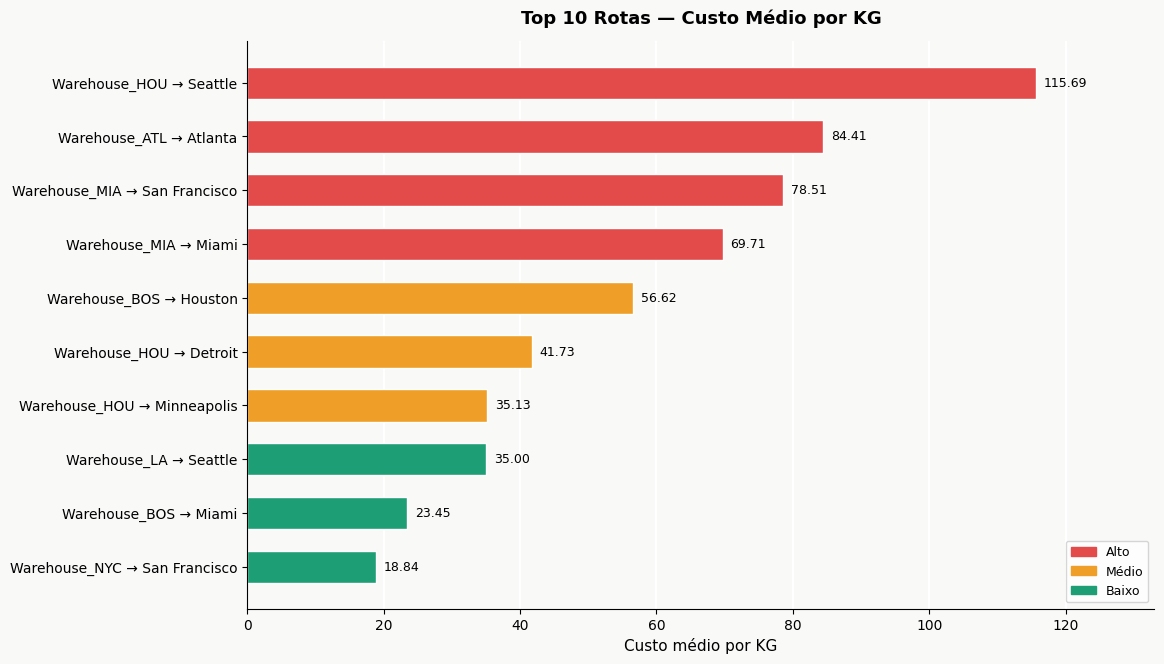

In [132]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f9f9f8')

custo_plot = custo_por_kg.nlargest(10, 'media_custo_por_kg').copy()
custo_plot['rota'] = custo_plot['armazem_origem'] + ' → ' + custo_plot['destino']
custo_plot = custo_plot.sort_values('media_custo_por_kg', ascending=True)

rotas  = custo_plot['rota'].tolist()
custos = custo_plot['media_custo_por_kg'].tolist()

def cor(i, total):
    t = i / (total - 1)
    if t >= 0.66: return '#E24B4A'
    if t >= 0.33: return '#EF9F27'
    return '#1D9E75'

cores = [cor(i, len(custos)) for i in range(len(custos))]

bars = ax.barh(rotas, custos, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Custo médio por KG', fontsize=11)
ax.set_title('Top 10 Rotas — Custo Médio por KG', fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, custos):
    ax.text(val + max(custos) * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9)

ax.set_xlim(0, max(custos) * 1.15)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('custo_por_kg_rotas.png', dpi=150, bbox_inches='tight')
plt.show()

# análise de evolução das entregas ao longo do tempo — envios

agrupamento por mês de envio para identificar padrões temporais
de volume e taxa de atraso ao longo de 2023.

**padrões identificados:**
- janeiro apresenta a menor taxa de atraso do ano (7.36%)
- dezembro concentra a maior taxa de atraso (14.29%) com 24 atrasos
- março apresenta pico intermediário de atraso (11.38%)
- há tendência de aumento de atrasos no segundo semestre, com pico em dezembro

**insight:** o aumento de atrasos em dezembro sugere impacto direto do volume de fim de ano na capacidade operacional das transportadoras.

a base está validada e pronta para visualização em gráfico de linha.

In [133]:
# Agrupa entregas por mes de envio considerando apenas atrasados pela coluna atraso_entregas
evolucao_entregas = (
    df.groupby(df['data_envio'].dt.to_period('M'))
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('atraso_entregas', lambda x: (x == 'ATRASADO').sum())
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_envios'] * 100).round(2))
)

print(evolucao_entregas)

            total_envios  total_atrasados  taxa_atraso
data_envio                                            
2023-01              163               12         7.36
2023-02              135               15        11.11
2023-03              167               19        11.38
2023-04              161               16         9.94
2023-05              172               15         8.72
2023-06              163               15         9.20
2023-07              165               16         9.70
2023-08              180               16         8.89
2023-09              161               16         9.94
2023-10              171               17         9.94
2023-11              177               15         8.47
2023-12              168               24        14.29


In [134]:
# Agrupa entregas por mes de envio considerando apenas atrasados pela coluna status
evolucao_entregas = (
    df.groupby(df['data_envio'].dt.to_period('M'))
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('status', lambda x: (x == 'DELAYED').sum())
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_envios'] * 100).round(2))
)

print(evolucao_entregas)

            total_envios  total_atrasados  taxa_atraso
data_envio                                            
2023-01              163               12         7.36
2023-02              135               15        11.11
2023-03              167               19        11.38
2023-04              161               16         9.94
2023-05              172               15         8.72
2023-06              163               15         9.20
2023-07              165               16         9.70
2023-08              180               16         8.89
2023-09              161               16         9.94
2023-10              171               17         9.94
2023-11              177               15         8.47
2023-12              168               24        14.29


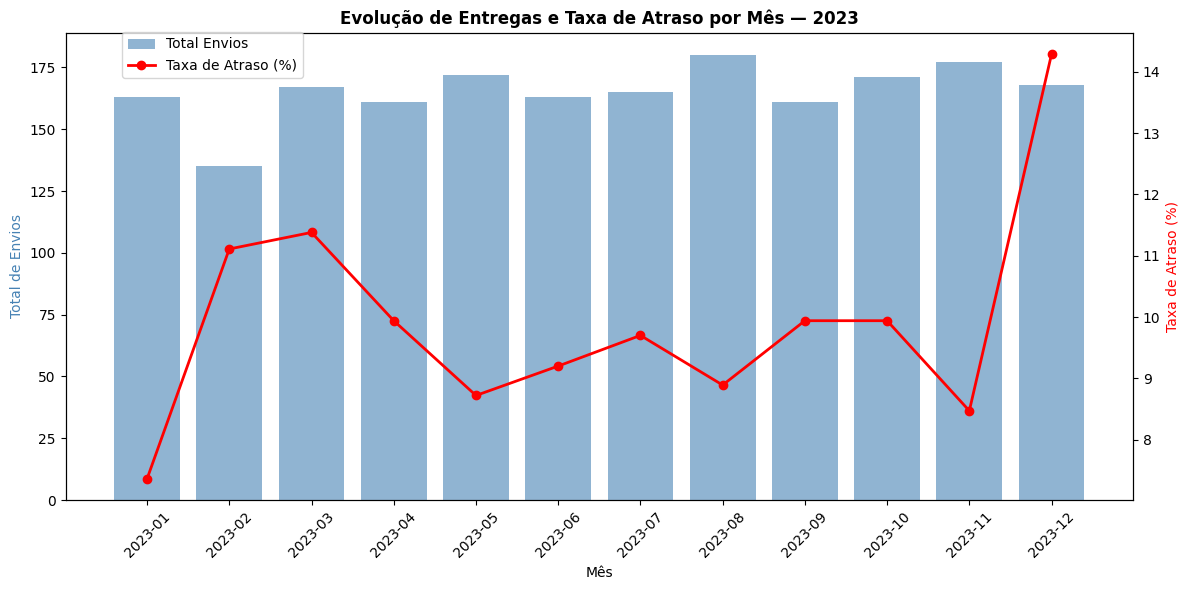

In [135]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo esquerdo - total de envios
ax1.bar(evolucao_entregas.index.astype(str),
        evolucao_entregas['total_envios'],
        color='steelblue', alpha=0.6, label='Total Envios')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Total de Envios', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

# Eixo direito - taxa de atraso
ax2 = ax1.twinx()
ax2.plot(evolucao_entregas.index.astype(str),
         evolucao_entregas['taxa_atraso'],
         color='red', marker='o', linewidth=2, label='Taxa de Atraso (%)')
ax2.set_ylabel('Taxa de Atraso (%)', color='red')

# Titulo e legenda
plt.title('Evolução de Entregas e Taxa de Atraso por Mês — 2023', fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))

plt.tight_layout()
plt.show()

# análise de evolução das entregas ao longo do tempo — entregas

agrupamento por mês de entrega para identificar padrões temporais
de volume e taxa de atraso ao longo de 2023.

**padrões identificados:**
- volume de entregas estável ao longo do ano (entre 128 e 178 por mês)
- janeiro/2023 apresenta a menor taxa de atraso (5.15%)
- dezembro/2023 inicia alta com taxa de 12.42%
- janeiro/2024 registra pico crítico de 28.95% com apenas 38 entregas — evidência de entregas de dezembro que atrasaram e chegaram no mês seguinte

**insight:** o pico de atrasos em janeiro/2024 não representa aumento de volume, mas sim o impacto das entregas atrasadas de dezembro.

isso sugere que o período de festas sobrecarrega a operação e gera efeito cascata no mês seguinte.

Base validada e gráfico gerado.

In [136]:
# Agrupa entregas por mes de entrega considerando apenas atrasados na coluna atraso_entregas
# nulos em data_entrega são excluídos automaticamente pelo groupby
evolucao_entregas = (
    df.groupby(df['data_entrega'].dt.to_period('M'))
    .agg(
        total_entregas=('id_envio', 'count'),
        total_atrasados=('atraso_entregas', lambda x: (x == 'ATRASADO').sum())
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_entregas'] * 100).round(2))
)

print(evolucao_entregas)

              total_entregas  total_atrasados  taxa_atraso
data_entrega                                              
2023-01                  136                7         5.15
2023-02                  128               11         8.59
2023-03                  168               17        10.12
2023-04                  152               15         9.87
2023-05                  170               17        10.00
2023-06                  156               14         8.97
2023-07                  167               16         9.58
2023-08                  178               16         8.99
2023-09                  169               19        11.24
2023-10                  163               12         7.36
2023-11                  166               16         9.64
2023-12                  161               20        12.42
2024-01                   38               11        28.95


In [137]:
# Agrupa entregas por mes de entrega considerando apenas atrasados pela coluna status
# nulos em data_entrega são excluídos automaticamente pelo groupby
evolucao_entregas = (
    df.groupby(df['data_entrega'].dt.to_period('M'))
    .agg(
        total_entregas=('id_envio', 'count'),
        total_atrasados=('status', lambda x: (x == 'DELAYED').sum())
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_entregas'] * 100).round(2))
)

print(evolucao_entregas)

              total_entregas  total_atrasados  taxa_atraso
data_entrega                                              
2023-01                  136                7         5.15
2023-02                  128               11         8.59
2023-03                  168               17        10.12
2023-04                  152               15         9.87
2023-05                  170               17        10.00
2023-06                  156               14         8.97
2023-07                  167               16         9.58
2023-08                  178               16         8.99
2023-09                  169               19        11.24
2023-10                  163               12         7.36
2023-11                  166               16         9.64
2023-12                  161               20        12.42
2024-01                   38               11        28.95


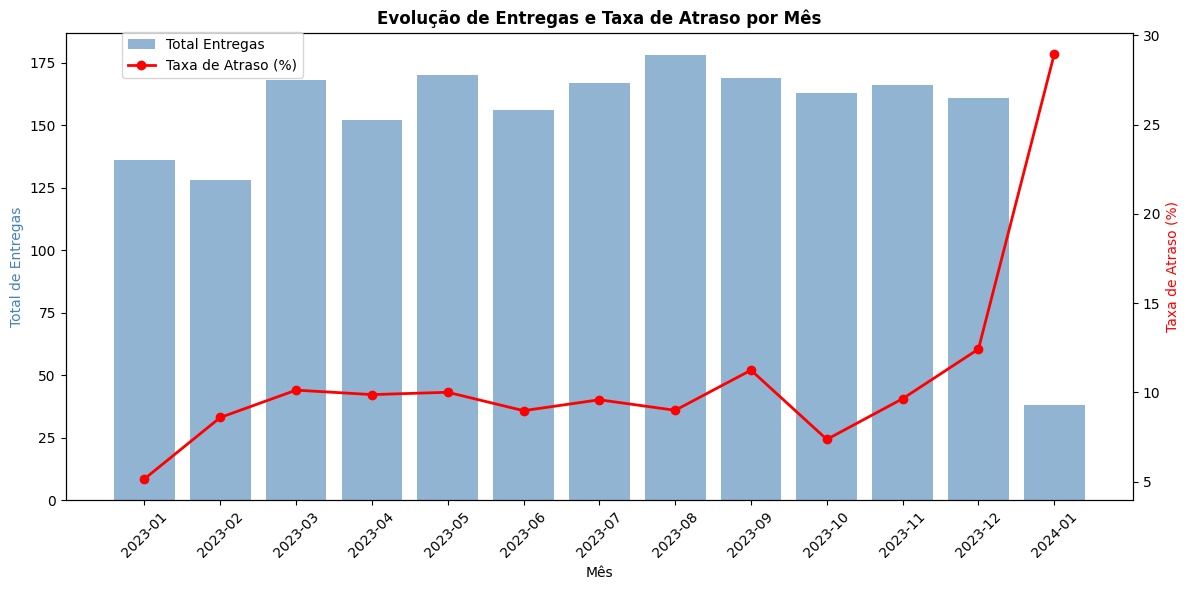

In [138]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo esquerdo - total de entregas
ax1.bar(evolucao_entregas.index.astype(str),
        evolucao_entregas['total_entregas'],
        color='steelblue', alpha=0.6, label='Total Entregas')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Total de Entregas', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

# Eixo direito - taxa de atraso
ax2 = ax1.twinx()
ax2.plot(evolucao_entregas.index.astype(str),
         evolucao_entregas['taxa_atraso'],
         color='red', marker='o', linewidth=2, label='Taxa de Atraso (%)')
ax2.set_ylabel('Taxa de Atraso (%)', color='red')

plt.title('Evolução de Entregas e Taxa de Atraso por Mês', fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))

plt.tight_layout()
plt.show()

# top 10 cidades que mais recebem entregas

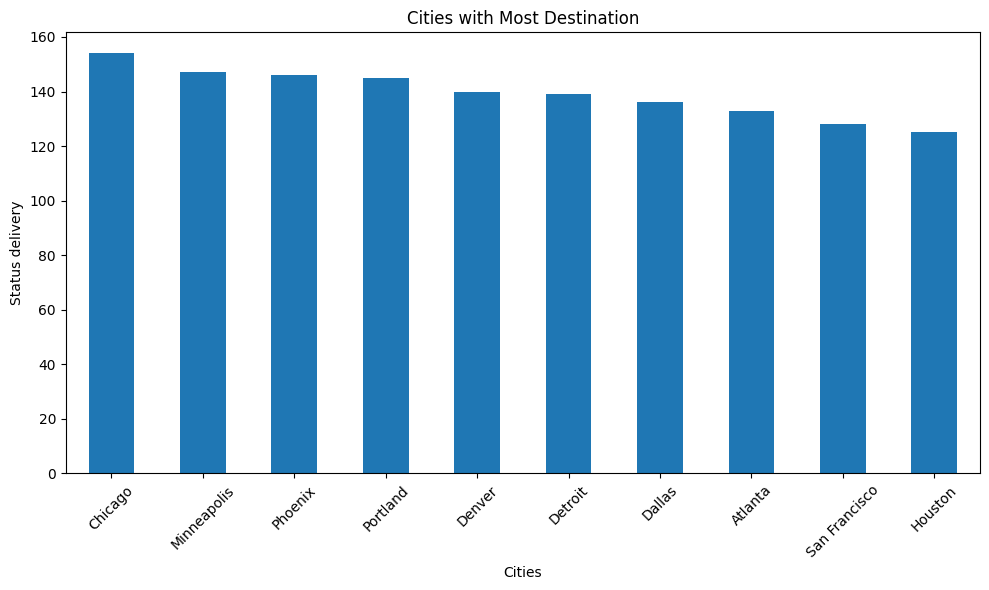

In [139]:
# top 10 cidades que mais recebem entregas
Destination_city = df['destino'].value_counts().head(10)

plt.figure(figsize=(10, 6))
Destination_city.plot(kind='bar')
plt.title('Cities with Most Destination')
plt.xlabel('Cities')
plt.ylabel('Status delivery')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# volume de entrega das transportadoras

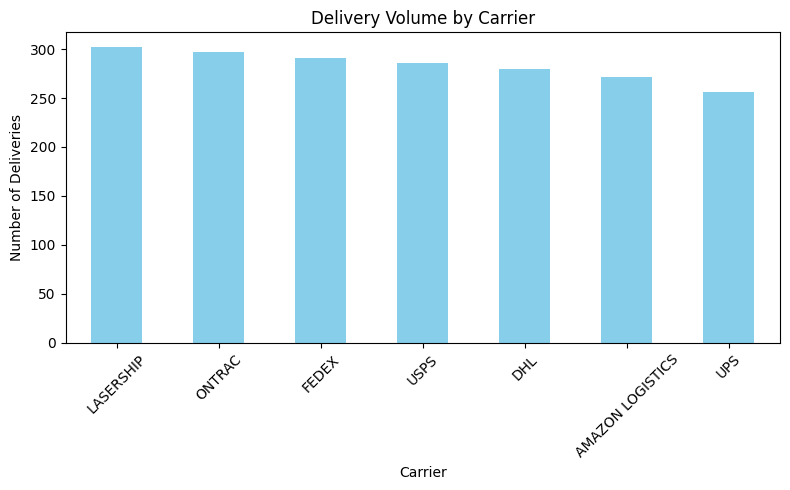

In [140]:
delivery_carrier = df['transportadora'].value_counts()

plt.figure(figsize=(8, 5))
delivery_carrier.plot(kind='bar', color='skyblue')
plt.title('Delivery Volume by Carrier')
plt.xlabel('Carrier')
plt.ylabel('Number of Deliveries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# volume de saídas dos depósitos de origem

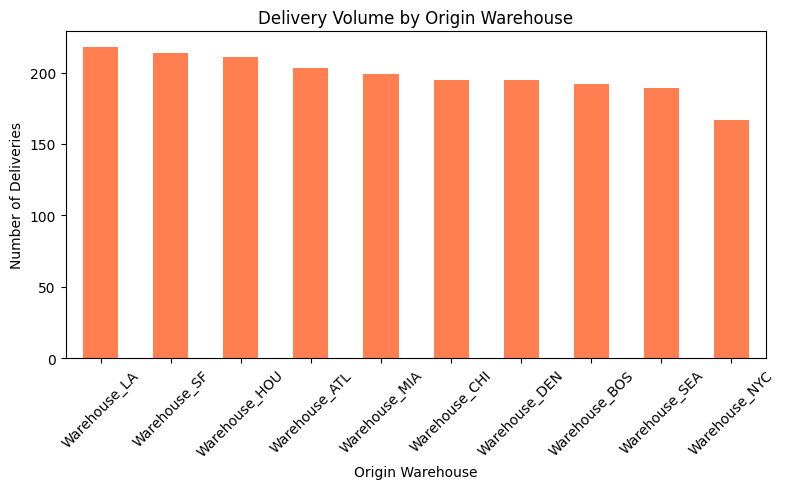

In [141]:
deliveries_warehouse = df['armazem_origem'].value_counts()

plt.figure(figsize=(8, 5))
deliveries_warehouse.plot(kind='bar', color='coral')
plt.title('Delivery Volume by Origin Warehouse')
plt.xlabel('Origin Warehouse')
plt.ylabel('Number of Deliveries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# mapa de volume de envios por cidade/estado

In [142]:
coords = {
    'San Francisco': (37.7749, -122.4194),
    'Los Angeles':   (34.0522, -118.2437),
    'New York':      (40.7128,  -74.0060),
    'Boston':        (42.3601,  -71.0589),
    'Chicago':       (41.8781,  -87.6298),
    'Houston':       (29.7604,  -95.3698),
    'Detroit':       (42.3314,  -83.0458),
    'Atlanta':       (33.7490,  -84.3880),
    'Miami':         (25.7617,  -80.1918),
    'Dallas':        (32.7767,  -96.7970),
    'Seattle':       (47.6062, -122.3321),
    'Denver':        (39.7392, -104.9903),
    'Phoenix':       (33.4484, -112.0740),
    'Portland':      (45.5051, -122.6750),
    'Minneapolis':   (44.9778,  -93.2650),
}

plot = (
    df.groupby('destino')['id_envio'].count()
    .reset_index(name='total_envios')
    .assign(
        lat=lambda x: x['destino'].map(lambda c: coords.get(c, (None, None))[0]),
        lon=lambda x: x['destino'].map(lambda c: coords.get(c, (None, None))[1]),
    )
    .dropna(subset=['lat', 'lon'])
)

fig = go.Figure()
fig.add_trace(go.Scattergeo(
    lon=plot['lon'],
    lat=plot['lat'],
    text=plot.apply(lambda r: f"{r['destino']}<br>{r['total_envios']:,} envios", axis=1),
    mode='markers',
    marker=dict(
        size=plot['total_envios'] / plot['total_envios'].max() * 50 + 8,
        color=plot['total_envios'],
        colorscale=[[0, '#7B0000'], [0.5, '#C0392B'], [1, '#FF1A1A']],
        showscale=True,
        colorbar=dict(title='Envios'),
        line=dict(color='white', width=0.8),
        opacity=0.85,
    ),
    hovertemplate='%{text}<extra></extra>',
))

fig.update_layout(
    title=dict(text='Volume de Envios por Cidade Destino — EUA', font=dict(size=16)),
    geo=dict(
        scope='usa',
        showland=True,
        landcolor='#f0f0ee',
        showlakes=True,
        lakecolor='#d0e4f7',
        showcoastlines=True,
        coastlinecolor='#aaaaaa',
        projection_type='albers usa',
    ),
    paper_bgcolor='#f9f9f8',
    margin=dict(l=0, r=0, t=40, b=0),
    height=550,
)

fig.show()

In [143]:
df['destino'].value_counts()

,count
destino,
Chicago,154
Minneapolis,147
Phoenix,146
Portland,145
Denver,140
Detroit,139
Dallas,136
Atlanta,133
San Francisco,128


# mapa de volume de envios por armazem

In [144]:
coords_armazem = {
    'Warehouse_MIA': (25.7617,  -80.1918),
    'Warehouse_LA':  (34.0522, -118.2437),
    'Warehouse_BOS': (42.3601,  -71.0589),
    'Warehouse_SF':  (37.7749, -122.4194),
    'Warehouse_ATL': (33.7490,  -84.3880),
    'Warehouse_CHI': (41.8781,  -87.6298),
    'Warehouse_HOU': (29.7604,  -95.3698),
    'Warehouse_SEA': (47.6062, -122.3321),
    'Warehouse_NYC': (40.7128,  -74.0060),
    'Warehouse_DEN': (39.7392, -104.9903),
}

plot = (
    df.groupby('armazem_origem')['id_envio'].count()
    .reset_index(name='total_envios')
    .assign(
        lat=lambda x: x['armazem_origem'].map(lambda c: coords_armazem.get(c, (None, None))[0]),
        lon=lambda x: x['armazem_origem'].map(lambda c: coords_armazem.get(c, (None, None))[1]),
    )
    .dropna(subset=['lat', 'lon'])
)

fig = go.Figure()
fig.add_trace(go.Scattergeo(
    lon=plot['lon'],
    lat=plot['lat'],
    text=plot.apply(lambda r: f"{r['armazem_origem']}<br>{r['total_envios']:,} envios", axis=1),
    mode='markers',
    marker=dict(
        size=plot['total_envios'] / plot['total_envios'].max() * 50 + 8,
        color=plot['total_envios'],
        colorscale=[[0, '#7B0000'], [0.5, '#C0392B'], [1, '#FF1A1A']],
        showscale=True,
        colorbar=dict(title='Envios'),
        line=dict(color='white', width=0.8),
        opacity=0.85,
    ),
    hovertemplate='%{text}<extra></extra>',
))

fig.update_layout(
    title=dict(text='Volume de Envios por Armazém — EUA', font=dict(size=16)),
    geo=dict(
        scope='usa',
        showland=True,
        landcolor='#f0f0ee',
        showlakes=True,
        lakecolor='#d0e4f7',
        showcoastlines=True,
        coastlinecolor='#aaaaaa',
        projection_type='albers usa',
    ),
    paper_bgcolor='#f9f9f8',
    margin=dict(l=0, r=0, t=40, b=0),
    height=550,
)

fig.show()

In [145]:
df['armazem_origem'].value_counts()

,count
armazem_origem,
Warehouse_LA,218
Warehouse_SF,214
Warehouse_HOU,211
Warehouse_ATL,203
Warehouse_MIA,199
Warehouse_CHI,195
Warehouse_DEN,195
Warehouse_BOS,192
Warehouse_SEA,189


# mapa de nulos por destino

In [146]:
# nulos por destino
nulos_destino = df.groupby('destino')[['custo', 'data_entrega']].apply(lambda x: x.isnull().sum()).reset_index()
nulos_destino['total_nulos'] = nulos_destino['custo'] + nulos_destino['data_entrega']

nulos_destino['lat'] = nulos_destino['destino'].map(lambda x: coords[x][0])
nulos_destino['lon'] = nulos_destino['destino'].map(lambda x: coords[x][1])

fig = px.scatter_geo(nulos_destino,
                     lat='lat', lon='lon',
                     size='total_nulos',
                     color='total_nulos',
                     hover_name='destino',
                     hover_data={'custo': True, 'data_entrega': True, 'total_nulos': True},
                     color_continuous_scale='Reds',
                     scope='usa',
                     title='Nulos por Destino — EUA')

fig.show()

In [147]:
nulos_destino = df.groupby('destino')[['custo', 'data_entrega']].apply(lambda x: x.isnull().sum()).reset_index()
nulos_destino['total_nulos'] = nulos_destino['custo'] + nulos_destino['data_entrega']
print(nulos_destino.sort_values('total_nulos', ascending=False))

          destino  custo  data_entrega  total_nulos
9     Minneapolis      4             5            9
2         Chicago      6             2            8
14        Seattle      4             3            7
13  San Francisco      2             4            6
5         Detroit      3             2            5
0         Atlanta      2             3            5
1          Boston      3             2            5
4          Denver      1             3            4
7     Los Angeles      2             2            4
6         Houston      1             2            3
3          Dallas      3             0            3
12       Portland      2             1            3
8           Miami      3             0            3
11        Phoenix      2             1            3
10       New York      1             1            2
